# Memcached RDMA/Hermit cgroup result summary

This notebook uses the latest valid Memcached results under `tools/rdma/results`, including `20260601-141933-hermit-6-local` for the extended local baseline. Hermit cgroup runs are not separated by run id in the final plot; repeated clean samples at the same offered load are collapsed into one representative point.

Selection rule: keep samples with zero miss rate, zero skipped transactions, zero evictions, zero backend errors, and about 32M resident items. For Hermit <=70K QPS, require achieved QPS >=95% of offered load and choose the lowest p99 representative. For Hermit >70K QPS, include clean high-load saturation points even when achieved QPS falls below offered QPS. Local clean baselines are merged by median at each offered load.


In [1]:
from pathlib import Path
import csv
import matplotlib.pyplot as plt
import numpy as np

RESULT_DIR = Path('results')
SELECTED_CSV = RESULT_DIR / 'memcached_selected_reasonable.csv'
COMPARISON_CSV = RESULT_DIR / 'memcached_comparison_reasonable.csv'
ALL_CLEAN_CSV = RESULT_DIR / 'memcached_all_clean_rows.csv'
HERMIT_CLEAN_CSV = RESULT_DIR / 'memcached_hermit_clean_rows.csv'

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 13,
    'axes.linewidth': 1.0,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})


## Data section

The following list is the concrete data used by the figures. It is also saved as `results/memcached_selected_reasonable.csv`; the common-load comparison table is `results/memcached_comparison_reasonable.csv`.


In [2]:
selected_rows = [
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 1000,
    "achieved_qps": 1004.5,
    "read_avg_us": 55.9,
    "read_p99_us": 76.80000000000001,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 40.0,
    "samples": 4,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 100.44999999999999
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 2000,
    "achieved_qps": 2001.6,
    "read_avg_us": 54.1,
    "read_p99_us": 73.6,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 40.0,
    "samples": 4,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 100.07999999999998
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 5000,
    "achieved_qps": 4983.8,
    "read_avg_us": 52.4,
    "read_p99_us": 71.75,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 40.0,
    "samples": 4,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.67600000000002
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 8000,
    "achieved_qps": 7994.85,
    "read_avg_us": 52.0,
    "read_p99_us": 72.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 40.0,
    "samples": 4,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.935625
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 10000,
    "achieved_qps": 9994.65,
    "read_avg_us": 51.25,
    "read_p99_us": 72.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 40.0,
    "samples": 4,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.9465
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 20000,
    "achieved_qps": 19967.2,
    "read_avg_us": 50.9,
    "read_p99_us": 72.5,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 40.0,
    "samples": 4,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.836
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 25000,
    "achieved_qps": 24985.2,
    "read_avg_us": 51.7,
    "read_p99_us": 75.85,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 40.0,
    "samples": 4,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.94080000000001
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 30000,
    "achieved_qps": 29964.199999999997,
    "read_avg_us": 52.05,
    "read_p99_us": 77.69999999999999,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 40.0,
    "samples": 4,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.88066666666666
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 40000,
    "achieved_qps": 39910.1,
    "read_avg_us": 51.5,
    "read_p99_us": 78.3,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 40.0,
    "samples": 3,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.77525
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 50000,
    "achieved_qps": 49963.5,
    "read_avg_us": 50.2,
    "read_p99_us": 75.7,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 40.0,
    "samples": 3,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.92699999999999
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 60000,
    "achieved_qps": 59852.6,
    "read_avg_us": 49.8,
    "read_p99_us": 76.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 40.0,
    "samples": 3,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.75433333333334
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 65000,
    "achieved_qps": 64795.4,
    "read_avg_us": 51.5,
    "read_p99_us": 78.6,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 40.0,
    "samples": 3,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.68523076923077
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 70000,
    "achieved_qps": 69912.3,
    "read_avg_us": 52.8,
    "read_p99_us": 81.2,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 40.0,
    "samples": 3,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.87471428571429
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 80000,
    "achieved_qps": 79626.35,
    "read_avg_us": 51.1,
    "read_p99_us": 77.6,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.5329375
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 100000,
    "achieved_qps": 99605.65,
    "read_avg_us": 51.7,
    "read_p99_us": 81.2,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.60565
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 120000,
    "achieved_qps": 119192.75,
    "read_avg_us": 52.099999999999994,
    "read_p99_us": 83.35,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.32729166666667
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 150000,
    "achieved_qps": 149371.75,
    "read_avg_us": 53.7,
    "read_p99_us": 89.25,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.58116666666666
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 200000,
    "achieved_qps": 198570.1,
    "read_avg_us": 55.05,
    "read_p99_us": 98.4,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.28505000000001
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 300000,
    "achieved_qps": 296848.5,
    "read_avg_us": 54.6,
    "read_p99_us": 114.6,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 98.9495
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 400000,
    "achieved_qps": 394629.75,
    "read_avg_us": 53.9,
    "read_p99_us": 128.8,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 98.6574375
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 500000,
    "achieved_qps": 490161.55000000005,
    "read_avg_us": 82.44999999999999,
    "read_p99_us": 261.6,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 98.03231000000001
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 600000,
    "achieved_qps": 560193.0,
    "read_avg_us": 493.6,
    "read_p99_us": 696.65,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 93.3655
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 800000,
    "achieved_qps": 658476.95,
    "read_avg_us": 497.4,
    "read_p99_us": 724.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 82.30961874999998
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 1000000,
    "achieved_qps": 985740.0,
    "read_avg_us": 110.6,
    "read_p99_us": 438.5,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 40.0,
    "samples": 3,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 98.574
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 1250000,
    "achieved_qps": 1145221.2,
    "read_avg_us": 878.7,
    "read_p99_us": 1592.4,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 40.0,
    "samples": 1,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 91.617696
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 1500000,
    "achieved_qps": 1163290.7,
    "read_avg_us": 864.8,
    "read_p99_us": 1623.6,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 40.0,
    "samples": 1,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 77.55271333333333
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 1750000,
    "achieved_qps": 1157536.4,
    "read_avg_us": 868.9,
    "read_p99_us": 1608.3,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 40.0,
    "samples": 1,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 66.14493714285715
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 2000000,
    "achieved_qps": 1151502.3,
    "read_avg_us": 878.5,
    "read_p99_us": 1621.3,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 40.0,
    "samples": 1,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 57.575115
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 1000,
    "achieved_qps": 1002.65,
    "read_avg_us": 2836.3500000000004,
    "read_p99_us": 23484.75,
    "pswpin_delta": 27306.5,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 420.1,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 100.265
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 2000,
    "achieved_qps": 1999.5500000000002,
    "read_avg_us": 5114.25,
    "read_p99_us": 41819.55,
    "pswpin_delta": 93870.5,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 1444.1615384615384,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.9775
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 5000,
    "achieved_qps": 4996.1,
    "read_avg_us": 29507.25,
    "read_p99_us": 151866.15,
    "pswpin_delta": 140694.5,
    "pswpout_delta": 101260.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 3722.376923076923,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.92200000000001
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 8000,
    "achieved_qps": 7240.65,
    "read_avg_us": 76671.70000000001,
    "read_p99_us": 227908.25,
    "pswpin_delta": 155692.0,
    "pswpout_delta": 131005.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 4410.723076923077,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 90.50812499999999
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 10000,
    "achieved_qps": 8424.599999999999,
    "read_avg_us": 70401.7,
    "read_p99_us": 218235.75,
    "pswpin_delta": 151572.5,
    "pswpout_delta": 119187.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 4165.530769230769,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 84.24599999999998
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 20000,
    "achieved_qps": 8034.25,
    "read_avg_us": 98210.54999999999,
    "read_p99_us": 383786.95,
    "pswpin_delta": 125735.5,
    "pswpout_delta": 126971.5,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 3887.8,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 40.17125
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 25000,
    "achieved_qps": 8008.200000000001,
    "read_avg_us": 108549.95,
    "read_p99_us": 357355.9,
    "pswpin_delta": 109999.5,
    "pswpout_delta": 107890.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 3352.146153846154,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 32.0328
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 30000,
    "achieved_qps": 8678.1,
    "read_avg_us": 101931.9,
    "read_p99_us": 322533.75,
    "pswpin_delta": 113856.0,
    "pswpout_delta": 106550.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 3390.8615384615387,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 28.927000000000003
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 40000,
    "achieved_qps": 9945.0,
    "read_avg_us": 80972.5,
    "read_p99_us": 234193.45,
    "pswpin_delta": 133879.5,
    "pswpout_delta": 121815.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 3933.7615384615383,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 24.8625
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 50000,
    "achieved_qps": 9128.2,
    "read_avg_us": 116927.4,
    "read_p99_us": 455315.9,
    "pswpin_delta": 103915.0,
    "pswpout_delta": 92803.5,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 3026.4384615384615,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 18.2564
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 60000,
    "achieved_qps": 8022.349999999999,
    "read_avg_us": 155356.59999999998,
    "read_p99_us": 598116.75,
    "pswpin_delta": 83284.5,
    "pswpout_delta": 79261.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 2500.7,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 13.370583333333332
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 65000,
    "achieved_qps": 6645.4,
    "read_avg_us": 171025.15000000002,
    "read_p99_us": 811400.55,
    "pswpin_delta": 77056.5,
    "pswpout_delta": 84034.5,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 2478.3230769230768,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 10.223692307692307
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 70000,
    "achieved_qps": 4306.2,
    "read_avg_us": 210097.65000000002,
    "read_p99_us": 1049707.5,
    "pswpin_delta": 57931.5,
    "pswpout_delta": 67724.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 1933.1615384615384,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 6.151714285714285
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 80000,
    "achieved_qps": 1856.5,
    "read_avg_us": 275051.5,
    "read_p99_us": 1345451.4,
    "pswpin_delta": 66151.0,
    "pswpout_delta": 74032.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 90.0,
    "samples": 1,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 1557.588888888889,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 2.320625
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 100000,
    "achieved_qps": 1856.1,
    "read_avg_us": 275516.0,
    "read_p99_us": 1138216.2,
    "pswpin_delta": 65640.0,
    "pswpout_delta": 76225.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 90.0,
    "samples": 1,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 1576.2777777777778,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 1.8560999999999999
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 120000,
    "achieved_qps": 1917.6,
    "read_avg_us": 266284.2,
    "read_p99_us": 1343975.3,
    "pswpin_delta": 61012.0,
    "pswpout_delta": 64665.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 90.0,
    "samples": 1,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 1396.411111111111,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 1.5979999999999999
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 150000,
    "achieved_qps": 1724.2,
    "read_avg_us": 296043.5,
    "read_p99_us": 1232681.7,
    "pswpin_delta": 60457.0,
    "pswpout_delta": 64630.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 90.0,
    "samples": 1,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 1389.8555555555556,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 1.1494666666666666
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 200000,
    "achieved_qps": 1832.6,
    "read_avg_us": 278280.7,
    "read_p99_us": 1187069.5,
    "pswpin_delta": 65550.0,
    "pswpout_delta": 60694.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 90.0,
    "samples": 1,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 1402.7111111111112,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 0.9162999999999999
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 300000,
    "achieved_qps": 1638.0,
    "read_avg_us": 311730.0,
    "read_p99_us": 1323367.3,
    "pswpin_delta": 57834.0,
    "pswpout_delta": 57709.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 90.0,
    "samples": 1,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 1283.8111111111111,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 0.5459999999999999
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 400000,
    "achieved_qps": 1796.7,
    "read_avg_us": 283826.4,
    "read_p99_us": 1293956.3,
    "pswpin_delta": 54576.0,
    "pswpout_delta": 56244.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 90.0,
    "samples": 1,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 1231.3333333333333,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 0.449175
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 500000,
    "achieved_qps": 1631.4,
    "read_avg_us": 313011.7,
    "read_p99_us": 1287409.0,
    "pswpin_delta": 56363.0,
    "pswpout_delta": 60596.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 90.0,
    "samples": 1,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 1299.5444444444445,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 0.32628
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 600000,
    "achieved_qps": 1689.8,
    "read_avg_us": 301887.5,
    "read_p99_us": 1314626.5,
    "pswpin_delta": 58885.0,
    "pswpout_delta": 60451.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 90.0,
    "samples": 1,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 1325.9555555555555,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 0.28163333333333335
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 800000,
    "achieved_qps": 1628.5,
    "read_avg_us": 312568.8,
    "read_p99_us": 1223741.9,
    "pswpin_delta": 57119.0,
    "pswpout_delta": 53779.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 90.0,
    "samples": 1,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 1232.2,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 0.2035625
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 1000000,
    "achieved_qps": 1650.7,
    "read_avg_us": 309611.7,
    "read_p99_us": 1181425.5,
    "pswpin_delta": 58118.0,
    "pswpout_delta": 57042.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 90.0,
    "samples": 1,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 1279.5555555555557,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 0.16507
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 1000,
    "achieved_qps": 993.6,
    "read_avg_us": 60.2,
    "read_p99_us": 128.9,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 32754.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 90.0,
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 363.93333333333334,
    "qps_efficiency_pct": 99.36,
    "samples": 7,
    "source": "20260603-151557-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 2000,
    "achieved_qps": 1992.6,
    "read_avg_us": 52.2,
    "read_p99_us": 114.4,
    "pswpin_delta": 0.0,
    "pswpout_delta": 74536.0,
    "backend_loads_delta": 73173.0,
    "backend_stores_delta": 72900.0,
    "duration_sec": 90.0,
    "swap_ops_per_s": 828.1777777777778,
    "backend_ops_per_s": 1623.0333333333333,
    "qps_efficiency_pct": 99.63,
    "samples": 7,
    "source": "20260603-151557-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 5000,
    "achieved_qps": 4988.0,
    "read_avg_us": 146.6,
    "read_p99_us": 171.4,
    "pswpin_delta": 0.0,
    "pswpout_delta": 890126.0,
    "backend_loads_delta": 904510.0,
    "backend_stores_delta": 890590.0,
    "duration_sec": 90.0,
    "swap_ops_per_s": 9890.288888888888,
    "backend_ops_per_s": 19945.555555555555,
    "qps_efficiency_pct": 99.76,
    "samples": 7,
    "source": "20260531-195546-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 8000,
    "achieved_qps": 7977.1,
    "read_avg_us": 56.4,
    "read_p99_us": 115.4,
    "pswpin_delta": 10.0,
    "pswpout_delta": 32883.0,
    "backend_loads_delta": 32880.0,
    "backend_stores_delta": 32883.0,
    "duration_sec": 40.0,
    "swap_ops_per_s": 822.325,
    "backend_ops_per_s": 1644.075,
    "qps_efficiency_pct": 99.71375,
    "samples": 7,
    "source": "20260531-214934-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 10000,
    "achieved_qps": 9975.5,
    "read_avg_us": 45.7,
    "read_p99_us": 108.6,
    "pswpin_delta": 0.0,
    "pswpout_delta": 67671.0,
    "backend_loads_delta": 70984.0,
    "backend_stores_delta": 67671.0,
    "duration_sec": 90.0,
    "swap_ops_per_s": 751.9,
    "backend_ops_per_s": 1540.611111111111,
    "qps_efficiency_pct": 99.75500000000001,
    "samples": 7,
    "source": "20260603-151557-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 20000,
    "achieved_qps": 19960.3,
    "read_avg_us": 1511.5,
    "read_p99_us": 4346.4,
    "pswpin_delta": 0.0,
    "pswpout_delta": 680848.0,
    "backend_loads_delta": 638837.0,
    "backend_stores_delta": 678398.0,
    "duration_sec": 90.0,
    "swap_ops_per_s": 7564.977777777778,
    "backend_ops_per_s": 14635.944444444445,
    "qps_efficiency_pct": 99.8015,
    "samples": 7,
    "source": "20260531-195546-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 25000,
    "achieved_qps": 25029.8,
    "read_avg_us": 44.8,
    "read_p99_us": 109.5,
    "pswpin_delta": 14.0,
    "pswpout_delta": 169160.0,
    "backend_loads_delta": 175041.0,
    "backend_stores_delta": 169160.0,
    "duration_sec": 90.0,
    "swap_ops_per_s": 1879.7111111111112,
    "backend_ops_per_s": 3824.4555555555557,
    "qps_efficiency_pct": 100.1192,
    "samples": 7,
    "source": "20260603-151557-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 30000,
    "achieved_qps": 30038.0,
    "read_avg_us": 52.8,
    "read_p99_us": 114.8,
    "pswpin_delta": 0.0,
    "pswpout_delta": 88609.0,
    "backend_loads_delta": 90985.0,
    "backend_stores_delta": 88609.0,
    "duration_sec": 40.0,
    "swap_ops_per_s": 2215.225,
    "backend_ops_per_s": 4489.85,
    "qps_efficiency_pct": 100.12666666666668,
    "samples": 7,
    "source": "20260531-234243-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 40000,
    "achieved_qps": 39996.3,
    "read_avg_us": 46.2,
    "read_p99_us": 115.4,
    "pswpin_delta": 70.0,
    "pswpout_delta": 300670.0,
    "backend_loads_delta": 300937.0,
    "backend_stores_delta": 300670.0,
    "duration_sec": 90.0,
    "swap_ops_per_s": 3341.5555555555557,
    "backend_ops_per_s": 6684.522222222222,
    "qps_efficiency_pct": 99.99075,
    "samples": 7,
    "source": "20260603-151557-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 50000,
    "achieved_qps": 49970.0,
    "read_avg_us": 62.1,
    "read_p99_us": 170.1,
    "pswpin_delta": 6.0,
    "pswpout_delta": 317753.0,
    "backend_loads_delta": 484576.0,
    "backend_stores_delta": 317753.0,
    "duration_sec": 40.0,
    "swap_ops_per_s": 7943.974999999999,
    "backend_ops_per_s": 20058.225,
    "qps_efficiency_pct": 99.94,
    "samples": 8,
    "source": "20260531-164619-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 60000,
    "achieved_qps": 59865.8,
    "read_avg_us": 55.4,
    "read_p99_us": 121.3,
    "pswpin_delta": 26.0,
    "pswpout_delta": 170986.0,
    "backend_loads_delta": 184077.0,
    "backend_stores_delta": 170986.0,
    "duration_sec": 40.0,
    "swap_ops_per_s": 4275.299999999999,
    "backend_ops_per_s": 8876.575,
    "qps_efficiency_pct": 99.77633333333333,
    "samples": 8,
    "source": "20260531-205825-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 65000,
    "achieved_qps": 65010.0,
    "read_avg_us": 57.3,
    "read_p99_us": 126.4,
    "pswpin_delta": 64.0,
    "pswpout_delta": 244890.0,
    "backend_loads_delta": 245392.0,
    "backend_stores_delta": 244890.0,
    "duration_sec": 40.0,
    "swap_ops_per_s": 6123.85,
    "backend_ops_per_s": 12257.05,
    "qps_efficiency_pct": 100.01538461538462,
    "samples": 7,
    "source": "20260531-221457-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 70000,
    "achieved_qps": 69981.8,
    "read_avg_us": 58.8,
    "read_p99_us": 132.8,
    "pswpin_delta": 63.0,
    "pswpout_delta": 295211.0,
    "backend_loads_delta": 294710.0,
    "backend_stores_delta": 295211.0,
    "duration_sec": 40.0,
    "swap_ops_per_s": 7381.849999999999,
    "backend_ops_per_s": 14748.025,
    "qps_efficiency_pct": 99.974,
    "samples": 7,
    "source": "20260531-221457-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 80000,
    "achieved_qps": 79645.4,
    "read_avg_us": 50.1,
    "read_p99_us": 147.8,
    "pswpin_delta": 115.0,
    "pswpout_delta": 760593.0,
    "backend_loads_delta": 764681.0,
    "backend_stores_delta": 760593.0,
    "duration_sec": 90.0,
    "swap_ops_per_s": 8452.31111111111,
    "backend_ops_per_s": 16947.48888888889,
    "qps_efficiency_pct": 99.55675,
    "samples": 7,
    "source": "20260603-151557-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 100000,
    "achieved_qps": 88147.2,
    "read_avg_us": 3135.0,
    "read_p99_us": 73996.4,
    "pswpin_delta": 139.0,
    "pswpout_delta": 1024169.0,
    "backend_loads_delta": 1037635.0,
    "backend_stores_delta": 1024615.0,
    "duration_sec": 90.0,
    "swap_ops_per_s": 11381.199999999999,
    "backend_ops_per_s": 22913.88888888889,
    "qps_efficiency_pct": 88.1472,
    "samples": 7,
    "source": "20260603-151557-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 120000,
    "achieved_qps": 42185.8,
    "read_avg_us": 12081.2,
    "read_p99_us": 349836.8,
    "pswpin_delta": 6.0,
    "pswpout_delta": 805168.0,
    "backend_loads_delta": 780977.0,
    "backend_stores_delta": 805659.0,
    "duration_sec": 90.0,
    "swap_ops_per_s": 8946.377777777778,
    "backend_ops_per_s": 17629.28888888889,
    "qps_efficiency_pct": 35.154833333333336,
    "samples": 6,
    "source": "20260603-151557-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 150000,
    "achieved_qps": 149393.2,
    "read_avg_us": 61.3,
    "read_p99_us": 184.2,
    "pswpin_delta": 177.0,
    "pswpout_delta": 608866.0,
    "backend_loads_delta": 615052.0,
    "backend_stores_delta": 608866.0,
    "duration_sec": 40.0,
    "swap_ops_per_s": 15226.074999999999,
    "backend_ops_per_s": 30597.949999999997,
    "qps_efficiency_pct": 99.59546666666668,
    "samples": 6,
    "source": "20260531-221457-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 200000,
    "achieved_qps": 153760.0,
    "read_avg_us": 2638.1,
    "read_p99_us": 3288.2,
    "pswpin_delta": 127.0,
    "pswpout_delta": 623722.0,
    "backend_loads_delta": 652401.0,
    "backend_stores_delta": 624701.0,
    "duration_sec": 40.0,
    "swap_ops_per_s": 15596.224999999999,
    "backend_ops_per_s": 31927.55,
    "qps_efficiency_pct": 76.88000000000001,
    "samples": 3,
    "source": "20260531-164619-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 300000,
    "achieved_qps": 59055.8,
    "read_avg_us": 8548.4,
    "read_p99_us": 282924.4,
    "pswpin_delta": 13.0,
    "pswpout_delta": 858100.0,
    "backend_loads_delta": 861089.0,
    "backend_stores_delta": 858495.0,
    "duration_sec": 90.0,
    "swap_ops_per_s": 9534.58888888889,
    "backend_ops_per_s": 19106.48888888889,
    "qps_efficiency_pct": 19.685266666666667,
    "samples": 2,
    "source": "20260603-151557-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 400000,
    "achieved_qps": 49988.6,
    "read_avg_us": 10169.6,
    "read_p99_us": 306257.3,
    "pswpin_delta": 0.0,
    "pswpout_delta": 820741.0,
    "backend_loads_delta": 807573.0,
    "backend_stores_delta": 819815.0,
    "duration_sec": 90.0,
    "swap_ops_per_s": 9119.344444444445,
    "backend_ops_per_s": 18082.088888888888,
    "qps_efficiency_pct": 12.49715,
    "samples": 2,
    "source": "20260603-151557-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 500000,
    "achieved_qps": 79334.6,
    "read_avg_us": 6399.7,
    "read_p99_us": 217289.0,
    "pswpin_delta": 9.0,
    "pswpout_delta": 844319.0,
    "backend_loads_delta": 847734.0,
    "backend_stores_delta": 844807.0,
    "duration_sec": 90.0,
    "swap_ops_per_s": 9381.422222222223,
    "backend_ops_per_s": 18806.01111111111,
    "qps_efficiency_pct": 15.86692,
    "samples": 2,
    "source": "20260603-151557-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 600000,
    "achieved_qps": 67172.3,
    "read_avg_us": 7562.9,
    "read_p99_us": 244676.9,
    "pswpin_delta": 4.0,
    "pswpout_delta": 838467.0,
    "backend_loads_delta": 843373.0,
    "backend_stores_delta": 838713.0,
    "duration_sec": 90.0,
    "swap_ops_per_s": 9316.344444444443,
    "backend_ops_per_s": 18689.844444444443,
    "qps_efficiency_pct": 11.195383333333334,
    "samples": 2,
    "source": "20260603-151557-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 800000,
    "achieved_qps": 64930.1,
    "read_avg_us": 15703.6,
    "read_p99_us": 415101.6,
    "pswpin_delta": 0.0,
    "pswpout_delta": 347307.0,
    "backend_loads_delta": 325403.0,
    "backend_stores_delta": 346834.0,
    "duration_sec": 40.0,
    "swap_ops_per_s": 8682.675,
    "backend_ops_per_s": 16805.925,
    "qps_efficiency_pct": 8.1162625,
    "samples": 1,
    "source": "20260531-234243-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 1000000,
    "achieved_qps": 48710.4,
    "read_avg_us": 10459.0,
    "read_p99_us": 317861.1,
    "pswpin_delta": 13.0,
    "pswpout_delta": 812579.0,
    "backend_loads_delta": 820061.0,
    "backend_stores_delta": 813069.0,
    "duration_sec": 90.0,
    "swap_ops_per_s": 9028.8,
    "backend_ops_per_s": 18145.88888888889,
    "qps_efficiency_pct": 4.87104,
    "samples": 2,
    "source": "20260603-151557-hermit-6-cgroup-hermit"
  }
]

comparison_rows = [
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 1000,
    "achieved_qps": 1004.5,
    "read_avg_us": 55.9,
    "read_p99_us": 76.80000000000001,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 40.0,
    "samples": 4,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 100.44999999999999
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 2000,
    "achieved_qps": 2001.6,
    "read_avg_us": 54.1,
    "read_p99_us": 73.6,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 40.0,
    "samples": 4,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 100.07999999999998
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 5000,
    "achieved_qps": 4983.8,
    "read_avg_us": 52.4,
    "read_p99_us": 71.75,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 40.0,
    "samples": 4,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.67600000000002
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 8000,
    "achieved_qps": 7994.85,
    "read_avg_us": 52.0,
    "read_p99_us": 72.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 40.0,
    "samples": 4,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.935625
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 10000,
    "achieved_qps": 9994.65,
    "read_avg_us": 51.25,
    "read_p99_us": 72.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 40.0,
    "samples": 4,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.9465
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 20000,
    "achieved_qps": 19967.2,
    "read_avg_us": 50.9,
    "read_p99_us": 72.5,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 40.0,
    "samples": 4,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.836
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 25000,
    "achieved_qps": 24985.2,
    "read_avg_us": 51.7,
    "read_p99_us": 75.85,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 40.0,
    "samples": 4,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.94080000000001
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 30000,
    "achieved_qps": 29964.199999999997,
    "read_avg_us": 52.05,
    "read_p99_us": 77.69999999999999,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 40.0,
    "samples": 4,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.88066666666666
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 40000,
    "achieved_qps": 39910.1,
    "read_avg_us": 51.5,
    "read_p99_us": 78.3,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 40.0,
    "samples": 3,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.77525
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 50000,
    "achieved_qps": 49963.5,
    "read_avg_us": 50.2,
    "read_p99_us": 75.7,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 40.0,
    "samples": 3,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.92699999999999
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 60000,
    "achieved_qps": 59852.6,
    "read_avg_us": 49.8,
    "read_p99_us": 76.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 40.0,
    "samples": 3,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.75433333333334
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 65000,
    "achieved_qps": 64795.4,
    "read_avg_us": 51.5,
    "read_p99_us": 78.6,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 40.0,
    "samples": 3,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.68523076923077
  },
  {
    "system": "All local",
    "mode": "local",
    "offered_qps": 70000,
    "achieved_qps": 69912.3,
    "read_avg_us": 52.8,
    "read_p99_us": 81.2,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 40.0,
    "samples": 3,
    "source": "median(local clean runs)",
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.87471428571429
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 1000,
    "achieved_qps": 1002.65,
    "read_avg_us": 2836.3500000000004,
    "read_p99_us": 23484.75,
    "pswpin_delta": 27306.5,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 420.1,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 100.265
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 2000,
    "achieved_qps": 1999.5500000000002,
    "read_avg_us": 5114.25,
    "read_p99_us": 41819.55,
    "pswpin_delta": 93870.5,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 1444.1615384615384,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.9775
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 5000,
    "achieved_qps": 4996.1,
    "read_avg_us": 29507.25,
    "read_p99_us": 151866.15,
    "pswpin_delta": 140694.5,
    "pswpout_delta": 101260.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 3722.376923076923,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.92200000000001
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 8000,
    "achieved_qps": 7240.65,
    "read_avg_us": 76671.70000000001,
    "read_p99_us": 227908.25,
    "pswpin_delta": 155692.0,
    "pswpout_delta": 131005.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 4410.723076923077,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 90.50812499999999
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 10000,
    "achieved_qps": 8424.599999999999,
    "read_avg_us": 70401.7,
    "read_p99_us": 218235.75,
    "pswpin_delta": 151572.5,
    "pswpout_delta": 119187.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 4165.530769230769,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 84.24599999999998
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 20000,
    "achieved_qps": 8034.25,
    "read_avg_us": 98210.54999999999,
    "read_p99_us": 383786.95,
    "pswpin_delta": 125735.5,
    "pswpout_delta": 126971.5,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 3887.8,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 40.17125
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 25000,
    "achieved_qps": 8008.200000000001,
    "read_avg_us": 108549.95,
    "read_p99_us": 357355.9,
    "pswpin_delta": 109999.5,
    "pswpout_delta": 107890.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 3352.146153846154,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 32.0328
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 30000,
    "achieved_qps": 8678.1,
    "read_avg_us": 101931.9,
    "read_p99_us": 322533.75,
    "pswpin_delta": 113856.0,
    "pswpout_delta": 106550.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 3390.8615384615387,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 28.927000000000003
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 40000,
    "achieved_qps": 9945.0,
    "read_avg_us": 80972.5,
    "read_p99_us": 234193.45,
    "pswpin_delta": 133879.5,
    "pswpout_delta": 121815.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 3933.7615384615383,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 24.8625
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 50000,
    "achieved_qps": 9128.2,
    "read_avg_us": 116927.4,
    "read_p99_us": 455315.9,
    "pswpin_delta": 103915.0,
    "pswpout_delta": 92803.5,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 3026.4384615384615,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 18.2564
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 60000,
    "achieved_qps": 8022.349999999999,
    "read_avg_us": 155356.59999999998,
    "read_p99_us": 598116.75,
    "pswpin_delta": 83284.5,
    "pswpout_delta": 79261.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 2500.7,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 13.370583333333332
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 65000,
    "achieved_qps": 6645.4,
    "read_avg_us": 171025.15000000002,
    "read_p99_us": 811400.55,
    "pswpin_delta": 77056.5,
    "pswpout_delta": 84034.5,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 2478.3230769230768,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 10.223692307692307
  },
  {
    "system": "Linux cgroup",
    "mode": "cgroup-linux",
    "offered_qps": 70000,
    "achieved_qps": 4306.2,
    "read_avg_us": 210097.65000000002,
    "read_p99_us": 1049707.5,
    "pswpin_delta": 57931.5,
    "pswpout_delta": 67724.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 65.0,
    "samples": 2,
    "source": "median(cgroup-linux clean runs)",
    "swap_ops_per_s": 1933.1615384615384,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 6.151714285714285
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 1000,
    "achieved_qps": 993.6,
    "read_avg_us": 60.2,
    "read_p99_us": 128.9,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 32754.0,
    "backend_stores_delta": 0.0,
    "duration_sec": 90.0,
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 363.93333333333334,
    "qps_efficiency_pct": 99.36,
    "samples": 7,
    "source": "20260603-151557-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 2000,
    "achieved_qps": 1992.6,
    "read_avg_us": 52.2,
    "read_p99_us": 114.4,
    "pswpin_delta": 0.0,
    "pswpout_delta": 74536.0,
    "backend_loads_delta": 73173.0,
    "backend_stores_delta": 72900.0,
    "duration_sec": 90.0,
    "swap_ops_per_s": 828.1777777777778,
    "backend_ops_per_s": 1623.0333333333333,
    "qps_efficiency_pct": 99.63,
    "samples": 7,
    "source": "20260603-151557-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 5000,
    "achieved_qps": 4988.0,
    "read_avg_us": 146.6,
    "read_p99_us": 171.4,
    "pswpin_delta": 0.0,
    "pswpout_delta": 890126.0,
    "backend_loads_delta": 904510.0,
    "backend_stores_delta": 890590.0,
    "duration_sec": 90.0,
    "swap_ops_per_s": 9890.288888888888,
    "backend_ops_per_s": 19945.555555555555,
    "qps_efficiency_pct": 99.76,
    "samples": 7,
    "source": "20260531-195546-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 8000,
    "achieved_qps": 7977.1,
    "read_avg_us": 56.4,
    "read_p99_us": 115.4,
    "pswpin_delta": 10.0,
    "pswpout_delta": 32883.0,
    "backend_loads_delta": 32880.0,
    "backend_stores_delta": 32883.0,
    "duration_sec": 40.0,
    "swap_ops_per_s": 822.325,
    "backend_ops_per_s": 1644.075,
    "qps_efficiency_pct": 99.71375,
    "samples": 7,
    "source": "20260531-214934-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 10000,
    "achieved_qps": 9975.5,
    "read_avg_us": 45.7,
    "read_p99_us": 108.6,
    "pswpin_delta": 0.0,
    "pswpout_delta": 67671.0,
    "backend_loads_delta": 70984.0,
    "backend_stores_delta": 67671.0,
    "duration_sec": 90.0,
    "swap_ops_per_s": 751.9,
    "backend_ops_per_s": 1540.611111111111,
    "qps_efficiency_pct": 99.75500000000001,
    "samples": 7,
    "source": "20260603-151557-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 20000,
    "achieved_qps": 19960.3,
    "read_avg_us": 1511.5,
    "read_p99_us": 4346.4,
    "pswpin_delta": 0.0,
    "pswpout_delta": 680848.0,
    "backend_loads_delta": 638837.0,
    "backend_stores_delta": 678398.0,
    "duration_sec": 90.0,
    "swap_ops_per_s": 7564.977777777778,
    "backend_ops_per_s": 14635.944444444445,
    "qps_efficiency_pct": 99.8015,
    "samples": 7,
    "source": "20260531-195546-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 25000,
    "achieved_qps": 25029.8,
    "read_avg_us": 44.8,
    "read_p99_us": 109.5,
    "pswpin_delta": 14.0,
    "pswpout_delta": 169160.0,
    "backend_loads_delta": 175041.0,
    "backend_stores_delta": 169160.0,
    "duration_sec": 90.0,
    "swap_ops_per_s": 1879.7111111111112,
    "backend_ops_per_s": 3824.4555555555557,
    "qps_efficiency_pct": 100.1192,
    "samples": 7,
    "source": "20260603-151557-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 30000,
    "achieved_qps": 30038.0,
    "read_avg_us": 52.8,
    "read_p99_us": 114.8,
    "pswpin_delta": 0.0,
    "pswpout_delta": 88609.0,
    "backend_loads_delta": 90985.0,
    "backend_stores_delta": 88609.0,
    "duration_sec": 40.0,
    "swap_ops_per_s": 2215.225,
    "backend_ops_per_s": 4489.85,
    "qps_efficiency_pct": 100.12666666666668,
    "samples": 7,
    "source": "20260531-234243-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 40000,
    "achieved_qps": 39996.3,
    "read_avg_us": 46.2,
    "read_p99_us": 115.4,
    "pswpin_delta": 70.0,
    "pswpout_delta": 300670.0,
    "backend_loads_delta": 300937.0,
    "backend_stores_delta": 300670.0,
    "duration_sec": 90.0,
    "swap_ops_per_s": 3341.5555555555557,
    "backend_ops_per_s": 6684.522222222222,
    "qps_efficiency_pct": 99.99075,
    "samples": 7,
    "source": "20260603-151557-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 50000,
    "achieved_qps": 49970.0,
    "read_avg_us": 62.1,
    "read_p99_us": 170.1,
    "pswpin_delta": 6.0,
    "pswpout_delta": 317753.0,
    "backend_loads_delta": 484576.0,
    "backend_stores_delta": 317753.0,
    "duration_sec": 40.0,
    "swap_ops_per_s": 7943.974999999999,
    "backend_ops_per_s": 20058.225,
    "qps_efficiency_pct": 99.94,
    "samples": 8,
    "source": "20260531-164619-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 60000,
    "achieved_qps": 59865.8,
    "read_avg_us": 55.4,
    "read_p99_us": 121.3,
    "pswpin_delta": 26.0,
    "pswpout_delta": 170986.0,
    "backend_loads_delta": 184077.0,
    "backend_stores_delta": 170986.0,
    "duration_sec": 40.0,
    "swap_ops_per_s": 4275.299999999999,
    "backend_ops_per_s": 8876.575,
    "qps_efficiency_pct": 99.77633333333333,
    "samples": 8,
    "source": "20260531-205825-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 65000,
    "achieved_qps": 65010.0,
    "read_avg_us": 57.3,
    "read_p99_us": 126.4,
    "pswpin_delta": 64.0,
    "pswpout_delta": 244890.0,
    "backend_loads_delta": 245392.0,
    "backend_stores_delta": 244890.0,
    "duration_sec": 40.0,
    "swap_ops_per_s": 6123.85,
    "backend_ops_per_s": 12257.05,
    "qps_efficiency_pct": 100.01538461538462,
    "samples": 7,
    "source": "20260531-221457-hermit-6-cgroup-hermit"
  },
  {
    "system": "Hermit cgroup",
    "mode": "cgroup-hermit",
    "offered_qps": 70000,
    "achieved_qps": 69981.8,
    "read_avg_us": 58.8,
    "read_p99_us": 132.8,
    "pswpin_delta": 63.0,
    "pswpout_delta": 295211.0,
    "backend_loads_delta": 294710.0,
    "backend_stores_delta": 295211.0,
    "duration_sec": 40.0,
    "swap_ops_per_s": 7381.849999999999,
    "backend_ops_per_s": 14748.025,
    "qps_efficiency_pct": 99.974,
    "samples": 7,
    "source": "20260531-221457-hermit-6-cgroup-hermit"
  }
]


In [3]:
def rows_for(system, rows=comparison_rows):
    return sorted([r for r in rows if r['system'] == system], key=lambda r: r['offered_qps'])

def rows_for_selected(system):
    return sorted([r for r in selected_rows if r['system'] == system],
                  key=lambda r: r['offered_qps'])

styles = {
    'Linux cgroup': dict(marker='x', color='#1f77b4', linestyle='-', linewidth=2, markersize=7, label='Linux cgroup'),
    'Hermit cgroup': dict(marker='^', color='#2ca02c', linestyle='-', linewidth=2, markersize=7, markerfacecolor='none', markeredgewidth=1.4, label='Hermit cgroup'),
    'All local': dict(marker='*', color='gray', linestyle='--', linewidth=2.2, label='All local'),
}

def savefig(fig, stem):
    for ext in ('png', 'pdf'):
        fig.savefig(RESULT_DIR / f'{stem}.{ext}', bbox_inches='tight', dpi=220)

def legend_top(fig, ax, ncol):
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=ncol, frameon=False)
    fig.tight_layout(rect=[0, 0, 1, 0.92])


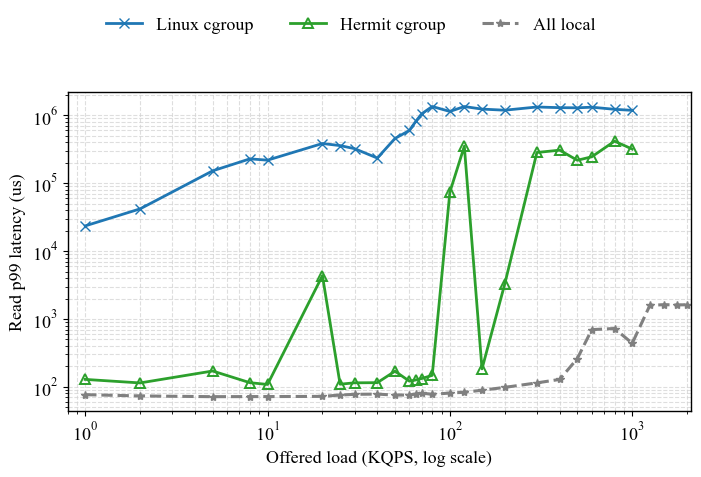

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 4.5))
for system in ['Linux cgroup', 'Hermit cgroup', 'All local']:
    rows = rows_for(system, selected_rows)
    ax.plot([r['offered_qps']/1000 for r in rows], [r['read_p99_us'] for r in rows], **styles[system])
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Offered load (KQPS, log scale)')
ax.set_ylabel('Read p99 latency (us)')
ax.set_xlim(0.8, 2100)
ax.grid(True, which='both', linestyle='--', color='lightgray', alpha=0.75)
legend_top(fig, ax, 3)
savefig(fig, 'memcached_latency_reasonable')
plt.show()


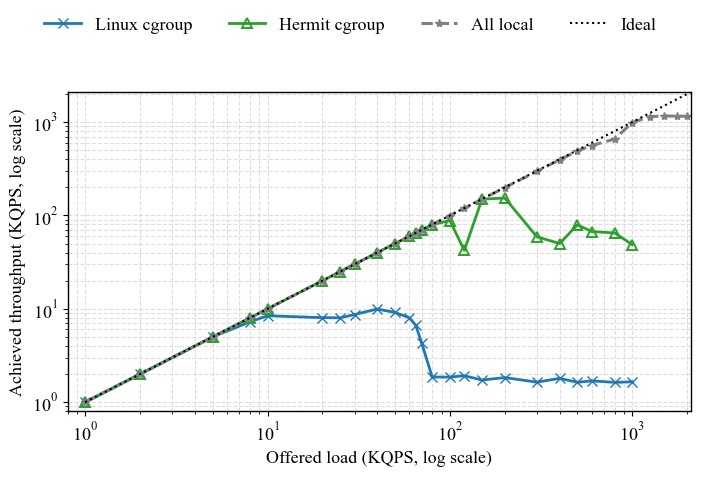

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 4.5))
for system in ['Linux cgroup', 'Hermit cgroup', 'All local']:
    rows = rows_for(system, selected_rows)
    ax.plot([r['offered_qps']/1000 for r in rows], [r['achieved_qps']/1000 for r in rows], **styles[system])
ax.plot([1, 2100], [1, 2100], color='black', linestyle=':', linewidth=1.5, label='Ideal')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Offered load (KQPS, log scale)')
ax.set_ylabel('Achieved throughput (KQPS, log scale)')
ax.set_xlim(0.8, 2100)
ax.set_ylim(0.8, 2100)
ax.grid(True, which='both', linestyle='--', color='lightgray', alpha=0.75)
legend_top(fig, ax, 4)
savefig(fig, 'memcached_throughput_reasonable')
plt.show()


KeyError: 'pswpin_per_s'

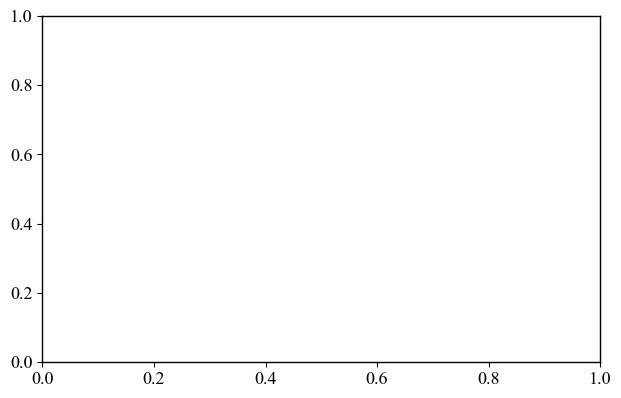

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 4.5))
linux = rows_for('Linux cgroup')
hermit = rows_for('Hermit cgroup')
ax.plot([r['offered_qps']/1000 for r in linux], [r['pswpin_per_s'] + r['pswpout_per_s'] for r in linux],
        marker='x', color='#1f77b4', linestyle='-', linewidth=2, markersize=7, label='Linux pswpin+pswpout')
ax.plot([r['offered_qps']/1000 for r in hermit], [r['backend_loads_per_s'] + r['backend_stores_per_s'] for r in hermit],
        marker='^', color='#2ca02c', linestyle='-', linewidth=2, markersize=7, markerfacecolor='none', markeredgewidth=1.4, label='Hermit backend loads+stores')
ax.set_xlabel('Offered load (KQPS)')
ax.set_ylabel('Swap/backend operations per second')
ax.grid(True, linestyle='--', color='lightgray', alpha=0.75)
legend_top(fig, ax, 2)
savefig(fig, 'memcached_swap_backend_reasonable')
plt.show()


## 151557 core-bound run

This section uses `20260603-151557-*`, where memcached is pinned to `16-23`, mutilate to `24-31`, and the run is bound to NUMA node 1.


In [ ]:
corebound_rows = 
[
  {
    "run_id": "20260603-151557-hermit-6-cgroup-hermit",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-hermit",
    "system": "Hermit cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 1000,
    "achieved_qps": 993.6,
    "read_avg_us": 60.2,
    "read_p99_us": 128.9,
    "update_avg_us": 71.0,
    "update_p99_us": 133.0,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 32754.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.0,
    "pswpout_per_s": 0.0,
    "backend_loads_per_s": 363.93333333333334,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 363.93333333333334,
    "qps_efficiency_pct": 99.36
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-hermit",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-hermit",
    "system": "Hermit cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 2000,
    "achieved_qps": 1992.6,
    "read_avg_us": 52.2,
    "read_p99_us": 114.4,
    "update_avg_us": 65.9,
    "update_p99_us": 211.0,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 74536.0,
    "backend_loads_delta": 73173.0,
    "backend_stores_delta": 72900.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.0,
    "pswpout_per_s": 828.1777777777778,
    "backend_loads_per_s": 813.0333333333333,
    "backend_stores_per_s": 810.0,
    "swap_ops_per_s": 828.1777777777778,
    "backend_ops_per_s": 1623.0333333333333,
    "qps_efficiency_pct": 99.63
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-hermit",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-hermit",
    "system": "Hermit cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 5000,
    "achieved_qps": 4995.9,
    "read_avg_us": 813.2,
    "read_p99_us": 1808.7,
    "update_avg_us": 2390.2,
    "update_p99_us": 85165.9,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 939453.0,
    "backend_loads_delta": 884744.0,
    "backend_stores_delta": 937823.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.0,
    "pswpout_per_s": 10438.366666666667,
    "backend_loads_per_s": 9830.488888888889,
    "backend_stores_per_s": 10420.255555555555,
    "swap_ops_per_s": 10438.366666666667,
    "backend_ops_per_s": 20250.744444444445,
    "qps_efficiency_pct": 99.91799999999999
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-hermit",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-hermit",
    "system": "Hermit cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 8000,
    "achieved_qps": 7991.2,
    "read_avg_us": 205.3,
    "read_p99_us": 216.2,
    "update_avg_us": 541.0,
    "update_p99_us": 557.7,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 967838.0,
    "backend_loads_delta": 985912.0,
    "backend_stores_delta": 970771.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.0,
    "pswpout_per_s": 10753.755555555555,
    "backend_loads_per_s": 10954.577777777778,
    "backend_stores_per_s": 10786.344444444445,
    "swap_ops_per_s": 10753.755555555555,
    "backend_ops_per_s": 21740.922222222223,
    "qps_efficiency_pct": 99.89
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-hermit",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-hermit",
    "system": "Hermit cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 10000,
    "achieved_qps": 9975.5,
    "read_avg_us": 45.7,
    "read_p99_us": 108.6,
    "update_avg_us": 57.2,
    "update_p99_us": 132.9,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 67671.0,
    "backend_loads_delta": 70984.0,
    "backend_stores_delta": 67671.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.0,
    "pswpout_per_s": 751.9,
    "backend_loads_per_s": 788.7111111111111,
    "backend_stores_per_s": 751.9,
    "swap_ops_per_s": 751.9,
    "backend_ops_per_s": 1540.611111111111,
    "qps_efficiency_pct": 99.75500000000001
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-hermit",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-hermit",
    "system": "Hermit cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 20000,
    "achieved_qps": 19988.0,
    "read_avg_us": 3438.9,
    "read_p99_us": 120638.2,
    "update_avg_us": 5156.5,
    "update_p99_us": 176951.9,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 18.0,
    "pswpout_delta": 1150803.0,
    "backend_loads_delta": 1121435.0,
    "backend_stores_delta": 1150803.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.2,
    "pswpout_per_s": 12786.7,
    "backend_loads_per_s": 12460.388888888889,
    "backend_stores_per_s": 12786.7,
    "swap_ops_per_s": 12786.900000000001,
    "backend_ops_per_s": 25247.088888888888,
    "qps_efficiency_pct": 99.94
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-hermit",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-hermit",
    "system": "Hermit cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 25000,
    "achieved_qps": 25029.8,
    "read_avg_us": 44.8,
    "read_p99_us": 109.5,
    "update_avg_us": 54.9,
    "update_p99_us": 121.2,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 14.0,
    "pswpout_delta": 169160.0,
    "backend_loads_delta": 175041.0,
    "backend_stores_delta": 169160.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.15555555555555556,
    "pswpout_per_s": 1879.5555555555557,
    "backend_loads_per_s": 1944.9,
    "backend_stores_per_s": 1879.5555555555557,
    "swap_ops_per_s": 1879.7111111111112,
    "backend_ops_per_s": 3824.4555555555557,
    "qps_efficiency_pct": 100.1192
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-hermit",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-hermit",
    "system": "Hermit cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 30000,
    "achieved_qps": 29925.8,
    "read_avg_us": 2048.2,
    "read_p99_us": 13286.3,
    "update_avg_us": 2165.7,
    "update_p99_us": 48775.7,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 37.0,
    "pswpout_delta": 1063813.0,
    "backend_loads_delta": 1059032.0,
    "backend_stores_delta": 1063813.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.4111111111111111,
    "pswpout_per_s": 11820.144444444444,
    "backend_loads_per_s": 11767.022222222222,
    "backend_stores_per_s": 11820.144444444444,
    "swap_ops_per_s": 11820.555555555555,
    "backend_ops_per_s": 23587.166666666664,
    "qps_efficiency_pct": 99.75266666666667
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-hermit",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-hermit",
    "system": "Hermit cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 40000,
    "achieved_qps": 39996.3,
    "read_avg_us": 46.2,
    "read_p99_us": 115.4,
    "update_avg_us": 56.0,
    "update_p99_us": 132.3,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 70.0,
    "pswpout_delta": 300670.0,
    "backend_loads_delta": 300937.0,
    "backend_stores_delta": 300670.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.7777777777777778,
    "pswpout_per_s": 3340.777777777778,
    "backend_loads_per_s": 3343.7444444444445,
    "backend_stores_per_s": 3340.777777777778,
    "swap_ops_per_s": 3341.5555555555557,
    "backend_ops_per_s": 6684.522222222222,
    "qps_efficiency_pct": 99.99075
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-hermit",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-hermit",
    "system": "Hermit cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 50000,
    "achieved_qps": 49843.1,
    "read_avg_us": 4571.7,
    "read_p99_us": 164983.3,
    "update_avg_us": 6398.0,
    "update_p99_us": 198097.8,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 22.0,
    "pswpout_delta": 1070882.0,
    "backend_loads_delta": 1026245.0,
    "backend_stores_delta": 1070938.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999977.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.24444444444444444,
    "pswpout_per_s": 11898.68888888889,
    "backend_loads_per_s": 11402.722222222223,
    "backend_stores_per_s": 11899.31111111111,
    "swap_ops_per_s": 11898.933333333334,
    "backend_ops_per_s": 23302.033333333333,
    "qps_efficiency_pct": 99.6862
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-hermit",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-hermit",
    "system": "Hermit cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 60000,
    "achieved_qps": 59759.8,
    "read_avg_us": 48.1,
    "read_p99_us": 125.7,
    "update_avg_us": 58.1,
    "update_p99_us": 147.9,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 133.0,
    "pswpout_delta": 500844.0,
    "backend_loads_delta": 500970.0,
    "backend_stores_delta": 500844.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 1.4777777777777779,
    "pswpout_per_s": 5564.933333333333,
    "backend_loads_per_s": 5566.333333333333,
    "backend_stores_per_s": 5564.933333333333,
    "swap_ops_per_s": 5566.4111111111115,
    "backend_ops_per_s": 11131.266666666666,
    "qps_efficiency_pct": 99.59966666666668
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-hermit",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-hermit",
    "system": "Hermit cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 65000,
    "achieved_qps": 64720.6,
    "read_avg_us": 48.8,
    "read_p99_us": 132.6,
    "update_avg_us": 58.8,
    "update_p99_us": 154.6,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 124.0,
    "pswpout_delta": 639008.0,
    "backend_loads_delta": 637893.0,
    "backend_stores_delta": 639008.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 1.3777777777777778,
    "pswpout_per_s": 7100.0888888888885,
    "backend_loads_per_s": 7087.7,
    "backend_stores_per_s": 7100.0888888888885,
    "swap_ops_per_s": 7101.466666666666,
    "backend_ops_per_s": 14187.788888888888,
    "qps_efficiency_pct": 99.57015384615384
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-hermit",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-hermit",
    "system": "Hermit cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 70000,
    "achieved_qps": 66734.0,
    "read_avg_us": 7520.7,
    "read_p99_us": 239536.4,
    "update_avg_us": 9812.9,
    "update_p99_us": 268633.0,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 19.0,
    "pswpout_delta": 902955.0,
    "backend_loads_delta": 871818.0,
    "backend_stores_delta": 902849.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999977.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.2111111111111111,
    "pswpout_per_s": 10032.833333333334,
    "backend_loads_per_s": 9686.866666666667,
    "backend_stores_per_s": 10031.655555555555,
    "swap_ops_per_s": 10033.044444444446,
    "backend_ops_per_s": 19718.522222222222,
    "qps_efficiency_pct": 95.33428571428571
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-hermit",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-hermit",
    "system": "Hermit cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 80000,
    "achieved_qps": 79645.4,
    "read_avg_us": 50.1,
    "read_p99_us": 147.8,
    "update_avg_us": 60.8,
    "update_p99_us": 175.1,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 115.0,
    "pswpout_delta": 760593.0,
    "backend_loads_delta": 764681.0,
    "backend_stores_delta": 760593.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 1.2777777777777777,
    "pswpout_per_s": 8451.033333333333,
    "backend_loads_per_s": 8496.455555555556,
    "backend_stores_per_s": 8451.033333333333,
    "swap_ops_per_s": 8452.31111111111,
    "backend_ops_per_s": 16947.48888888889,
    "qps_efficiency_pct": 99.55675
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-hermit",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-hermit",
    "system": "Hermit cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 100000,
    "achieved_qps": 88147.2,
    "read_avg_us": 3135.0,
    "read_p99_us": 73996.4,
    "update_avg_us": 3871.6,
    "update_p99_us": 127165.5,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 139.0,
    "pswpout_delta": 1024169.0,
    "backend_loads_delta": 1037635.0,
    "backend_stores_delta": 1024615.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 1.5444444444444445,
    "pswpout_per_s": 11379.655555555555,
    "backend_loads_per_s": 11529.277777777777,
    "backend_stores_per_s": 11384.611111111111,
    "swap_ops_per_s": 11381.199999999999,
    "backend_ops_per_s": 22913.88888888889,
    "qps_efficiency_pct": 88.1472
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-hermit",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-hermit",
    "system": "Hermit cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 120000,
    "achieved_qps": 42185.8,
    "read_avg_us": 12081.2,
    "read_p99_us": 349836.8,
    "update_avg_us": 16290.1,
    "update_p99_us": 400741.7,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 6.0,
    "pswpout_delta": 805168.0,
    "backend_loads_delta": 780977.0,
    "backend_stores_delta": 805659.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.06666666666666667,
    "pswpout_per_s": 8946.31111111111,
    "backend_loads_per_s": 8677.522222222222,
    "backend_stores_per_s": 8951.766666666666,
    "swap_ops_per_s": 8946.377777777778,
    "backend_ops_per_s": 17629.28888888889,
    "qps_efficiency_pct": 35.154833333333336
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-hermit",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-hermit",
    "system": "Hermit cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 150000,
    "achieved_qps": 76827.4,
    "read_avg_us": 5969.5,
    "read_p99_us": 197603.7,
    "update_avg_us": 7739.4,
    "update_p99_us": 247477.0,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 145.0,
    "pswpout_delta": 956390.0,
    "backend_loads_delta": 956149.0,
    "backend_stores_delta": 957770.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 1.6111111111111112,
    "pswpout_per_s": 10626.555555555555,
    "backend_loads_per_s": 10623.877777777778,
    "backend_stores_per_s": 10641.888888888889,
    "swap_ops_per_s": 10628.166666666666,
    "backend_ops_per_s": 21265.766666666666,
    "qps_efficiency_pct": 51.218266666666665
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-hermit",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-hermit",
    "system": "Hermit cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 200000,
    "achieved_qps": 78697.1,
    "read_avg_us": 6347.6,
    "read_p99_us": 212212.3,
    "update_avg_us": 7824.9,
    "update_p99_us": 250977.0,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 20.0,
    "pswpout_delta": 858530.0,
    "backend_loads_delta": 864439.0,
    "backend_stores_delta": 859586.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.2222222222222222,
    "pswpout_per_s": 9539.222222222223,
    "backend_loads_per_s": 9604.877777777778,
    "backend_stores_per_s": 9550.955555555556,
    "swap_ops_per_s": 9539.444444444445,
    "backend_ops_per_s": 19155.833333333336,
    "qps_efficiency_pct": 39.34855
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-hermit",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-hermit",
    "system": "Hermit cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 300000,
    "achieved_qps": 59055.8,
    "read_avg_us": 8548.4,
    "read_p99_us": 282924.4,
    "update_avg_us": 10027.3,
    "update_p99_us": 283389.2,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 13.0,
    "pswpout_delta": 858100.0,
    "backend_loads_delta": 861089.0,
    "backend_stores_delta": 858495.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999976.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.14444444444444443,
    "pswpout_per_s": 9534.444444444445,
    "backend_loads_per_s": 9567.655555555555,
    "backend_stores_per_s": 9538.833333333334,
    "swap_ops_per_s": 9534.58888888889,
    "backend_ops_per_s": 19106.48888888889,
    "qps_efficiency_pct": 19.685266666666667
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-hermit",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-hermit",
    "system": "Hermit cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 400000,
    "achieved_qps": 49988.6,
    "read_avg_us": 10169.6,
    "read_p99_us": 306257.3,
    "update_avg_us": 14001.9,
    "update_p99_us": 318031.8,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 820741.0,
    "backend_loads_delta": 807573.0,
    "backend_stores_delta": 819815.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999977.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.0,
    "pswpout_per_s": 9119.344444444445,
    "backend_loads_per_s": 8973.033333333333,
    "backend_stores_per_s": 9109.055555555555,
    "swap_ops_per_s": 9119.344444444445,
    "backend_ops_per_s": 18082.088888888888,
    "qps_efficiency_pct": 12.49715
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-hermit",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-hermit",
    "system": "Hermit cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 500000,
    "achieved_qps": 79334.6,
    "read_avg_us": 6399.7,
    "read_p99_us": 217289.0,
    "update_avg_us": 8572.8,
    "update_p99_us": 269189.6,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 9.0,
    "pswpout_delta": 844319.0,
    "backend_loads_delta": 847734.0,
    "backend_stores_delta": 844807.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.1,
    "pswpout_per_s": 9381.322222222223,
    "backend_loads_per_s": 9419.266666666666,
    "backend_stores_per_s": 9386.744444444445,
    "swap_ops_per_s": 9381.422222222223,
    "backend_ops_per_s": 18806.01111111111,
    "qps_efficiency_pct": 15.86692
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-hermit",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-hermit",
    "system": "Hermit cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 600000,
    "achieved_qps": 67172.3,
    "read_avg_us": 7562.9,
    "read_p99_us": 244676.9,
    "update_avg_us": 9360.4,
    "update_p99_us": 258895.9,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 4.0,
    "pswpout_delta": 838467.0,
    "backend_loads_delta": 843373.0,
    "backend_stores_delta": 838713.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999977.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.044444444444444446,
    "pswpout_per_s": 9316.3,
    "backend_loads_per_s": 9370.81111111111,
    "backend_stores_per_s": 9319.033333333333,
    "swap_ops_per_s": 9316.344444444443,
    "backend_ops_per_s": 18689.844444444443,
    "qps_efficiency_pct": 11.195383333333334
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-hermit",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-hermit",
    "system": "Hermit cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 1000000,
    "achieved_qps": 48710.4,
    "read_avg_us": 10459.0,
    "read_p99_us": 317861.1,
    "update_avg_us": 13643.1,
    "update_p99_us": 357748.3,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 13.0,
    "pswpout_delta": 812579.0,
    "backend_loads_delta": 820061.0,
    "backend_stores_delta": 813069.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.14444444444444443,
    "pswpout_per_s": 9028.655555555555,
    "backend_loads_per_s": 9111.788888888888,
    "backend_stores_per_s": 9034.1,
    "swap_ops_per_s": 9028.8,
    "backend_ops_per_s": 18145.88888888889,
    "qps_efficiency_pct": 4.87104
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-linux",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-linux",
    "system": "Linux cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 1000,
    "achieved_qps": 992.9,
    "read_avg_us": 3064.9,
    "read_p99_us": 23769.0,
    "update_avg_us": 3143.9,
    "update_p99_us": 27243.9,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 36110.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 401.22222222222223,
    "pswpout_per_s": 0.0,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 401.22222222222223,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.29
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-linux",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-linux",
    "system": "Linux cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 2000,
    "achieved_qps": 2001.4,
    "read_avg_us": 6388.8,
    "read_p99_us": 48416.2,
    "update_avg_us": 6237.3,
    "update_p99_us": 43739.6,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 152958.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 1699.5333333333333,
    "pswpout_per_s": 0.0,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 1699.5333333333333,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 100.07000000000002
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-linux",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-linux",
    "system": "Linux cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 5000,
    "achieved_qps": 4994.2,
    "read_avg_us": 39651.8,
    "read_p99_us": 178328.8,
    "update_avg_us": 38478.0,
    "update_p99_us": 160115.1,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 202172.0,
    "pswpout_delta": 202520.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 2246.3555555555554,
    "pswpout_per_s": 2250.222222222222,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 4496.577777777778,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.884
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-linux",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-linux",
    "system": "Linux cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 8000,
    "achieved_qps": 6498.5,
    "read_avg_us": 78394.3,
    "read_p99_us": 196478.5,
    "update_avg_us": 80692.7,
    "update_p99_us": 194834.6,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 199509.0,
    "pswpout_delta": 199973.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 2216.766666666667,
    "pswpout_per_s": 2221.9222222222224,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 4438.68888888889,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 81.23125
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-linux",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-linux",
    "system": "Linux cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 10000,
    "achieved_qps": 6912.9,
    "read_avg_us": 73808.7,
    "read_p99_us": 203222.0,
    "update_avg_us": 76188.3,
    "update_p99_us": 212700.9,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 182787.0,
    "pswpout_delta": 117473.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 2030.9666666666667,
    "pswpout_per_s": 1305.2555555555555,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 3336.222222222222,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 69.12899999999999
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-linux",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-linux",
    "system": "Linux cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 20000,
    "achieved_qps": 4828.5,
    "read_avg_us": 105836.7,
    "read_p99_us": 518703.5,
    "update_avg_us": 102271.7,
    "update_p99_us": 520609.3,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 133749.0,
    "pswpout_delta": 135439.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 1486.1,
    "pswpout_per_s": 1504.8777777777777,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 2990.9777777777776,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 24.1425
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-linux",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-linux",
    "system": "Linux cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 25000,
    "achieved_qps": 3831.3,
    "read_avg_us": 133360.3,
    "read_p99_us": 477573.6,
    "update_avg_us": 132853.9,
    "update_p99_us": 460501.3,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 108511.0,
    "pswpout_delta": 103911.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 1205.6777777777777,
    "pswpout_per_s": 1154.5666666666666,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 2360.2444444444445,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 15.3252
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-linux",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-linux",
    "system": "Linux cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 30000,
    "achieved_qps": 4017.6,
    "read_avg_us": 127336.2,
    "read_p99_us": 411448.4,
    "update_avg_us": 120496.7,
    "update_p99_us": 352179.9,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 115669.0,
    "pswpout_delta": 99819.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 1285.2111111111112,
    "pswpout_per_s": 1109.1,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 2394.311111111111,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 13.391999999999998
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-linux",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-linux",
    "system": "Linux cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 40000,
    "achieved_qps": 5674.0,
    "read_avg_us": 90084.7,
    "read_p99_us": 247771.2,
    "update_avg_us": 89674.0,
    "update_p99_us": 245352.9,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 155562.0,
    "pswpout_delta": 129728.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 1728.4666666666667,
    "pswpout_per_s": 1441.4222222222222,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 3169.8888888888887,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 14.185
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-linux",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-linux",
    "system": "Linux cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 50000,
    "achieved_qps": 3067.3,
    "read_avg_us": 166593.4,
    "read_p99_us": 694858.4,
    "update_avg_us": 170842.6,
    "update_p99_us": 658003.8,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 95448.0,
    "pswpout_delta": 98187.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 1060.5333333333333,
    "pswpout_per_s": 1090.9666666666667,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 2151.5,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 6.134600000000001
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-linux",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-linux",
    "system": "Linux cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 60000,
    "achieved_qps": 2150.4,
    "read_avg_us": 237213.3,
    "read_p99_us": 951993.4,
    "update_avg_us": 233986.9,
    "update_p99_us": 980429.0,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 68086.0,
    "pswpout_delta": 79771.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 756.5111111111111,
    "pswpout_per_s": 886.3444444444444,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 1642.8555555555554,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 3.5840000000000005
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-linux",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-linux",
    "system": "Linux cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 65000,
    "achieved_qps": 2026.5,
    "read_avg_us": 252219.7,
    "read_p99_us": 1068128.0,
    "update_avg_us": 260410.8,
    "update_p99_us": 1117077.2,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 71126.0,
    "pswpout_delta": 86021.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 790.2888888888889,
    "pswpout_per_s": 955.7888888888889,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 1746.0777777777778,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 3.117692307692308
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-linux",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-linux",
    "system": "Linux cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 70000,
    "achieved_qps": 1907.2,
    "read_avg_us": 267929.2,
    "read_p99_us": 1093658.9,
    "update_avg_us": 276205.6,
    "update_p99_us": 1139175.7,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 64648.0,
    "pswpout_delta": 77257.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 718.3111111111111,
    "pswpout_per_s": 858.4111111111112,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 1576.7222222222222,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 2.7245714285714286
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-linux",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-linux",
    "system": "Linux cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 80000,
    "achieved_qps": 1856.5,
    "read_avg_us": 275051.5,
    "read_p99_us": 1345451.4,
    "update_avg_us": 294563.3,
    "update_p99_us": 1441908.0,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 66151.0,
    "pswpout_delta": 74032.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 735.0111111111111,
    "pswpout_per_s": 822.5777777777778,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 1557.588888888889,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 2.320625
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-linux",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-linux",
    "system": "Linux cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 100000,
    "achieved_qps": 1856.1,
    "read_avg_us": 275516.0,
    "read_p99_us": 1138216.2,
    "update_avg_us": 273391.3,
    "update_p99_us": 1249447.0,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 65640.0,
    "pswpout_delta": 76225.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 729.3333333333334,
    "pswpout_per_s": 846.9444444444445,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 1576.2777777777778,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 1.8560999999999999
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-linux",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-linux",
    "system": "Linux cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 120000,
    "achieved_qps": 1917.6,
    "read_avg_us": 266284.2,
    "read_p99_us": 1343975.3,
    "update_avg_us": 268514.2,
    "update_p99_us": 1060056.5,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 61012.0,
    "pswpout_delta": 64665.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 677.9111111111112,
    "pswpout_per_s": 718.5,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 1396.411111111111,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 1.5979999999999999
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-linux",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-linux",
    "system": "Linux cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 150000,
    "achieved_qps": 1724.2,
    "read_avg_us": 296043.5,
    "read_p99_us": 1232681.7,
    "update_avg_us": 298284.6,
    "update_p99_us": 1322371.9,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 60457.0,
    "pswpout_delta": 64630.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 671.7444444444444,
    "pswpout_per_s": 718.1111111111111,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 1389.8555555555554,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 1.1494666666666666
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-linux",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-linux",
    "system": "Linux cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 200000,
    "achieved_qps": 1832.6,
    "read_avg_us": 278280.7,
    "read_p99_us": 1187069.5,
    "update_avg_us": 284905.1,
    "update_p99_us": 1199062.5,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 65550.0,
    "pswpout_delta": 60694.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 728.3333333333334,
    "pswpout_per_s": 674.3777777777777,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 1402.7111111111112,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 0.9162999999999999
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-linux",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-linux",
    "system": "Linux cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 300000,
    "achieved_qps": 1638.0,
    "read_avg_us": 311730.0,
    "read_p99_us": 1323367.3,
    "update_avg_us": 274305.4,
    "update_p99_us": 1231215.8,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 57834.0,
    "pswpout_delta": 57709.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 642.6,
    "pswpout_per_s": 641.2111111111111,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 1283.8111111111111,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 0.5459999999999999
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-linux",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-linux",
    "system": "Linux cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 400000,
    "achieved_qps": 1796.7,
    "read_avg_us": 283826.4,
    "read_p99_us": 1293956.3,
    "update_avg_us": 273312.5,
    "update_p99_us": 1162379.0,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 54576.0,
    "pswpout_delta": 56244.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 606.4,
    "pswpout_per_s": 624.9333333333333,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 1231.3333333333333,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 0.449175
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-linux",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-linux",
    "system": "Linux cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 500000,
    "achieved_qps": 1631.4,
    "read_avg_us": 313011.7,
    "read_p99_us": 1287409.0,
    "update_avg_us": 312680.8,
    "update_p99_us": 1189725.9,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 56363.0,
    "pswpout_delta": 60596.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 626.2555555555556,
    "pswpout_per_s": 673.2888888888889,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 1299.5444444444445,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 0.32628
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-linux",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-linux",
    "system": "Linux cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 600000,
    "achieved_qps": 1689.8,
    "read_avg_us": 301887.5,
    "read_p99_us": 1314626.5,
    "update_avg_us": 287462.0,
    "update_p99_us": 1436783.0,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 58885.0,
    "pswpout_delta": 60451.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 654.2777777777778,
    "pswpout_per_s": 671.6777777777778,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 1325.9555555555557,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 0.28163333333333335
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-linux",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-linux",
    "system": "Linux cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 800000,
    "achieved_qps": 1628.5,
    "read_avg_us": 312568.8,
    "read_p99_us": 1223741.9,
    "update_avg_us": 326019.0,
    "update_p99_us": 1148751.7,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 57119.0,
    "pswpout_delta": 53779.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 634.6555555555556,
    "pswpout_per_s": 597.5444444444445,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 1232.2,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 0.2035625
  },
  {
    "run_id": "20260603-151557-hermit-6-cgroup-linux",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "cgroup-linux",
    "system": "Linux cgroup",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 1000000,
    "achieved_qps": 1650.7,
    "read_avg_us": 309611.7,
    "read_p99_us": 1181425.5,
    "update_avg_us": 327144.0,
    "update_p99_us": 1256739.5,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 58118.0,
    "pswpout_delta": 57042.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 645.7555555555556,
    "pswpout_per_s": 633.8,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 1279.5555555555557,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 0.16507
  },
  {
    "run_id": "20260603-151557-hermit-6-local",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "local",
    "system": "All local",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 1000,
    "achieved_qps": 998.8,
    "read_avg_us": 53.3,
    "read_p99_us": 65.7,
    "update_avg_us": 59.9,
    "update_p99_us": 78.4,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.0,
    "pswpout_per_s": 0.0,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.88
  },
  {
    "run_id": "20260603-151557-hermit-6-local",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "local",
    "system": "All local",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 2000,
    "achieved_qps": 2006.0,
    "read_avg_us": 52.0,
    "read_p99_us": 65.0,
    "update_avg_us": 58.3,
    "update_p99_us": 77.7,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.0,
    "pswpout_per_s": 0.0,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 100.29999999999998
  },
  {
    "run_id": "20260603-151557-hermit-6-local",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "local",
    "system": "All local",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 5000,
    "achieved_qps": 4980.3,
    "read_avg_us": 51.1,
    "read_p99_us": 65.9,
    "update_avg_us": 56.9,
    "update_p99_us": 77.8,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.0,
    "pswpout_per_s": 0.0,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.60600000000001
  },
  {
    "run_id": "20260603-151557-hermit-6-local",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "local",
    "system": "All local",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 8000,
    "achieved_qps": 7998.2,
    "read_avg_us": 50.5,
    "read_p99_us": 66.1,
    "update_avg_us": 55.9,
    "update_p99_us": 72.9,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.0,
    "pswpout_per_s": 0.0,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.97749999999999
  },
  {
    "run_id": "20260603-151557-hermit-6-local",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "local",
    "system": "All local",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 10000,
    "achieved_qps": 9993.8,
    "read_avg_us": 50.2,
    "read_p99_us": 66.1,
    "update_avg_us": 55.6,
    "update_p99_us": 72.5,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.0,
    "pswpout_per_s": 0.0,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.93799999999999
  },
  {
    "run_id": "20260603-151557-hermit-6-local",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "local",
    "system": "All local",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 20000,
    "achieved_qps": 19926.5,
    "read_avg_us": 49.3,
    "read_p99_us": 67.5,
    "update_avg_us": 55.7,
    "update_p99_us": 74.3,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.0,
    "pswpout_per_s": 0.0,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.63250000000001
  },
  {
    "run_id": "20260603-151557-hermit-6-local",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "local",
    "system": "All local",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 25000,
    "achieved_qps": 24912.4,
    "read_avg_us": 49.4,
    "read_p99_us": 68.0,
    "update_avg_us": 55.0,
    "update_p99_us": 75.8,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.0,
    "pswpout_per_s": 0.0,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.6496
  },
  {
    "run_id": "20260603-151557-hermit-6-local",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "local",
    "system": "All local",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 30000,
    "achieved_qps": 30005.9,
    "read_avg_us": 49.0,
    "read_p99_us": 68.1,
    "update_avg_us": 54.5,
    "update_p99_us": 76.9,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.0,
    "pswpout_per_s": 0.0,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 100.01966666666667
  },
  {
    "run_id": "20260603-151557-hermit-6-local",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "local",
    "system": "All local",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 40000,
    "achieved_qps": 39910.1,
    "read_avg_us": 49.1,
    "read_p99_us": 69.3,
    "update_avg_us": 54.4,
    "update_p99_us": 76.4,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.0,
    "pswpout_per_s": 0.0,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.77525
  },
  {
    "run_id": "20260603-151557-hermit-6-local",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "local",
    "system": "All local",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 50000,
    "achieved_qps": 49963.5,
    "read_avg_us": 49.4,
    "read_p99_us": 70.8,
    "update_avg_us": 54.4,
    "update_p99_us": 76.9,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.0,
    "pswpout_per_s": 0.0,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.92699999999999
  },
  {
    "run_id": "20260603-151557-hermit-6-local",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "local",
    "system": "All local",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 60000,
    "achieved_qps": 59754.7,
    "read_avg_us": 49.4,
    "read_p99_us": 71.7,
    "update_avg_us": 54.4,
    "update_p99_us": 77.8,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.0,
    "pswpout_per_s": 0.0,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.59116666666667
  },
  {
    "run_id": "20260603-151557-hermit-6-local",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "local",
    "system": "All local",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 65000,
    "achieved_qps": 64579.9,
    "read_avg_us": 49.7,
    "read_p99_us": 72.3,
    "update_avg_us": 54.7,
    "update_p99_us": 78.7,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.0,
    "pswpout_per_s": 0.0,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.35369230769231
  },
  {
    "run_id": "20260603-151557-hermit-6-local",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "local",
    "system": "All local",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 70000,
    "achieved_qps": 69912.3,
    "read_avg_us": 49.6,
    "read_p99_us": 72.7,
    "update_avg_us": 54.6,
    "update_p99_us": 79.1,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.0,
    "pswpout_per_s": 0.0,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.87471428571429
  },
  {
    "run_id": "20260603-151557-hermit-6-local",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "local",
    "system": "All local",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 80000,
    "achieved_qps": 79408.6,
    "read_avg_us": 50.2,
    "read_p99_us": 75.0,
    "update_avg_us": 55.2,
    "update_p99_us": 80.1,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.0,
    "pswpout_per_s": 0.0,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.26075
  },
  {
    "run_id": "20260603-151557-hermit-6-local",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "local",
    "system": "All local",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 100000,
    "achieved_qps": 99389.5,
    "read_avg_us": 50.7,
    "read_p99_us": 78.2,
    "update_avg_us": 55.8,
    "update_p99_us": 83.9,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.0,
    "pswpout_per_s": 0.0,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.3895
  },
  {
    "run_id": "20260603-151557-hermit-6-local",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "local",
    "system": "All local",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 120000,
    "achieved_qps": 118672.2,
    "read_avg_us": 51.8,
    "read_p99_us": 81.3,
    "update_avg_us": 56.9,
    "update_p99_us": 86.9,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.0,
    "pswpout_per_s": 0.0,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 98.8935
  },
  {
    "run_id": "20260603-151557-hermit-6-local",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "local",
    "system": "All local",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 150000,
    "achieved_qps": 149179.3,
    "read_avg_us": 53.6,
    "read_p99_us": 87.8,
    "update_avg_us": 58.8,
    "update_p99_us": 94.3,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.0,
    "pswpout_per_s": 0.0,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.45286666666667
  },
  {
    "run_id": "20260603-151557-hermit-6-local",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "local",
    "system": "All local",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 200000,
    "achieved_qps": 198005.0,
    "read_avg_us": 56.3,
    "read_p99_us": 99.9,
    "update_avg_us": 61.4,
    "update_p99_us": 104.7,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.0,
    "pswpout_per_s": 0.0,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 99.0025
  },
  {
    "run_id": "20260603-151557-hermit-6-local",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "local",
    "system": "All local",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 300000,
    "achieved_qps": 294678.3,
    "read_avg_us": 58.1,
    "read_p99_us": 121.4,
    "update_avg_us": 62.6,
    "update_p99_us": 126.9,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.0,
    "pswpout_per_s": 0.0,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 98.22609999999999
  },
  {
    "run_id": "20260603-151557-hermit-6-local",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "local",
    "system": "All local",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 400000,
    "achieved_qps": 391799.1,
    "read_avg_us": 65.8,
    "read_p99_us": 171.0,
    "update_avg_us": 69.7,
    "update_p99_us": 178.3,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.0,
    "pswpout_per_s": 0.0,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 97.94977499999999
  },
  {
    "run_id": "20260603-151557-hermit-6-local",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "local",
    "system": "All local",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 500000,
    "achieved_qps": 484172.2,
    "read_avg_us": 124.6,
    "read_p99_us": 441.8,
    "update_avg_us": 128.6,
    "update_p99_us": 443.2,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.0,
    "pswpout_per_s": 0.0,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 96.83444
  },
  {
    "run_id": "20260603-151557-hermit-6-local",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "local",
    "system": "All local",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 600000,
    "achieved_qps": 525515.1,
    "read_avg_us": 944.6,
    "read_p99_us": 1303.8,
    "update_avg_us": 945.2,
    "update_p99_us": 1328.5,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.0,
    "pswpout_per_s": 0.0,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 87.58585
  },
  {
    "run_id": "20260603-151557-hermit-6-local",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "local",
    "system": "All local",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 800000,
    "achieved_qps": 523459.3,
    "read_avg_us": 937.5,
    "read_p99_us": 1299.0,
    "update_avg_us": 938.4,
    "update_p99_us": 1327.5,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.0,
    "pswpout_per_s": 0.0,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 65.4324125
  },
  {
    "run_id": "20260603-151557-hermit-6-local",
    "kernel_tag": "hermit-6",
    "uname": "6.6.138-hermit",
    "mode": "local",
    "system": "All local",
    "duration_sec": 90.0,
    "records": 32000000.0,
    "memcached_threads": 8.0,
    "mutilate_threads": 8.0,
    "memcached_cores": "16-23",
    "mutilate_cores": "24-31",
    "hermit_reserved_cores": "",
    "sthd_cnt": 16.0,
    "local_ratio_pct": 80.0,
    "cgroup_limit_mb": "",
    "offered_qps": 1000000,
    "achieved_qps": 528337.8,
    "read_avg_us": 930.4,
    "read_p99_us": 1294.7,
    "update_avg_us": 930.8,
    "update_p99_us": 1322.5,
    "miss_rate_pct": 0.0,
    "skipped_txs_pct": 0.0,
    "pswpin_delta": 0.0,
    "pswpout_delta": 0.0,
    "backend_loads_delta": 0.0,
    "backend_stores_delta": 0.0,
    "backend_load_misses_delta": 0.0,
    "backend_errors_delta": 0.0,
    "memcached_curr_items": 31999978.0,
    "memcached_evictions": 0.0,
    "memcached_bytes": 0.0,
    "pswpin_per_s": 0.0,
    "pswpout_per_s": 0.0,
    "backend_loads_per_s": 0.0,
    "backend_stores_per_s": 0.0,
    "swap_ops_per_s": 0.0,
    "backend_ops_per_s": 0.0,
    "qps_efficiency_pct": 52.833780000000004
  }
]


corebound_change_rows = 
[
  {
    "system": "All local",
    "offered_qps": 1000,
    "before_p99_us": 77.7,
    "after_p99_us": 65.7,
    "p99_ratio_after_over_before": 0.8455598455598455,
    "before_achieved_qps": 1005.1,
    "after_achieved_qps": 998.8,
    "qps_ratio_after_over_before": 0.9937319669684608,
    "after_swap_ops_per_s": 0.0,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "All local",
    "offered_qps": 2000,
    "before_p99_us": 74.7,
    "after_p99_us": 65.0,
    "p99_ratio_after_over_before": 0.8701472556894243,
    "before_achieved_qps": 1997.2,
    "after_achieved_qps": 2006.0,
    "qps_ratio_after_over_before": 1.0044061686360906,
    "after_swap_ops_per_s": 0.0,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "All local",
    "offered_qps": 5000,
    "before_p99_us": 71.8,
    "after_p99_us": 65.9,
    "p99_ratio_after_over_before": 0.9178272980501394,
    "before_achieved_qps": 4987.3,
    "after_achieved_qps": 4980.3,
    "qps_ratio_after_over_before": 0.9985964349447597,
    "after_swap_ops_per_s": 0.0,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "All local",
    "offered_qps": 8000,
    "before_p99_us": 72.6,
    "after_p99_us": 66.1,
    "p99_ratio_after_over_before": 0.9104683195592287,
    "before_achieved_qps": 7991.5,
    "after_achieved_qps": 7998.2,
    "qps_ratio_after_over_before": 1.0008383907902145,
    "after_swap_ops_per_s": 0.0,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "All local",
    "offered_qps": 10000,
    "before_p99_us": 72.4,
    "after_p99_us": 66.1,
    "p99_ratio_after_over_before": 0.9129834254143645,
    "before_achieved_qps": 9995.5,
    "after_achieved_qps": 9993.8,
    "qps_ratio_after_over_before": 0.9998299234655594,
    "after_swap_ops_per_s": 0.0,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "All local",
    "offered_qps": 20000,
    "before_p99_us": 72.7,
    "after_p99_us": 67.5,
    "p99_ratio_after_over_before": 0.9284731774415406,
    "before_achieved_qps": 19969.5,
    "after_achieved_qps": 19926.5,
    "qps_ratio_after_over_before": 0.9978467162422695,
    "after_swap_ops_per_s": 0.0,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "All local",
    "offered_qps": 25000,
    "before_p99_us": 76.1,
    "after_p99_us": 68.0,
    "p99_ratio_after_over_before": 0.8935611038107754,
    "before_achieved_qps": 24988.5,
    "after_achieved_qps": 24912.4,
    "qps_ratio_after_over_before": 0.9969545991155933,
    "after_swap_ops_per_s": 0.0,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "All local",
    "offered_qps": 30000,
    "before_p99_us": 77.8,
    "after_p99_us": 68.1,
    "p99_ratio_after_over_before": 0.8753213367609254,
    "before_achieved_qps": 29947.8,
    "after_achieved_qps": 30005.9,
    "qps_ratio_after_over_before": 1.0019400423403388,
    "after_swap_ops_per_s": 0.0,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "All local",
    "offered_qps": 40000,
    "before_p99_us": 78.69999999999999,
    "after_p99_us": 69.3,
    "p99_ratio_after_over_before": 0.8805590851334182,
    "before_achieved_qps": 39931.0,
    "after_achieved_qps": 39910.1,
    "qps_ratio_after_over_before": 0.9994765971300493,
    "after_swap_ops_per_s": 0.0,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "All local",
    "offered_qps": 50000,
    "before_p99_us": 77.35,
    "after_p99_us": 70.8,
    "p99_ratio_after_over_before": 0.9153199741435036,
    "before_achieved_qps": 49978.649999999994,
    "after_achieved_qps": 49963.5,
    "qps_ratio_after_over_before": 0.9996968705637308,
    "after_swap_ops_per_s": 0.0,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "All local",
    "offered_qps": 60000,
    "before_p99_us": 78.0,
    "after_p99_us": 71.7,
    "p99_ratio_after_over_before": 0.9192307692307693,
    "before_achieved_qps": 59908.0,
    "after_achieved_qps": 59754.7,
    "qps_ratio_after_over_before": 0.9974410763170194,
    "after_swap_ops_per_s": 0.0,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "All local",
    "offered_qps": 65000,
    "before_p99_us": 80.1,
    "after_p99_us": 72.3,
    "p99_ratio_after_over_before": 0.9026217228464419,
    "before_achieved_qps": 64915.8,
    "after_achieved_qps": 64579.9,
    "qps_ratio_after_over_before": 0.99482560486045,
    "after_swap_ops_per_s": 0.0,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "All local",
    "offered_qps": 70000,
    "before_p99_us": 81.5,
    "after_p99_us": 72.7,
    "p99_ratio_after_over_before": 0.8920245398773007,
    "before_achieved_qps": 69881.6,
    "after_achieved_qps": 69912.3,
    "qps_ratio_after_over_before": 1.0004393144976647,
    "after_swap_ops_per_s": 0.0,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "All local",
    "offered_qps": 80000,
    "before_p99_us": 80.2,
    "after_p99_us": 75.0,
    "p99_ratio_after_over_before": 0.9351620947630922,
    "before_achieved_qps": 79844.1,
    "after_achieved_qps": 79408.6,
    "qps_ratio_after_over_before": 0.9945456207784921,
    "after_swap_ops_per_s": 0.0,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "All local",
    "offered_qps": 100000,
    "before_p99_us": 84.2,
    "after_p99_us": 78.2,
    "p99_ratio_after_over_before": 0.9287410926365796,
    "before_achieved_qps": 99821.8,
    "after_achieved_qps": 99389.5,
    "qps_ratio_after_over_before": 0.9956692826617032,
    "after_swap_ops_per_s": 0.0,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "All local",
    "offered_qps": 120000,
    "before_p99_us": 85.4,
    "after_p99_us": 81.3,
    "p99_ratio_after_over_before": 0.9519906323185011,
    "before_achieved_qps": 119713.3,
    "after_achieved_qps": 118672.2,
    "qps_ratio_after_over_before": 0.991303389013585,
    "after_swap_ops_per_s": 0.0,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "All local",
    "offered_qps": 150000,
    "before_p99_us": 90.7,
    "after_p99_us": 87.8,
    "p99_ratio_after_over_before": 0.9680264608599779,
    "before_achieved_qps": 149564.2,
    "after_achieved_qps": 149179.3,
    "qps_ratio_after_over_before": 0.9974265231920472,
    "after_swap_ops_per_s": 0.0,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "All local",
    "offered_qps": 200000,
    "before_p99_us": 96.9,
    "after_p99_us": 99.9,
    "p99_ratio_after_over_before": 1.0309597523219813,
    "before_achieved_qps": 199135.2,
    "after_achieved_qps": 198005.0,
    "qps_ratio_after_over_before": 0.9943244589605453,
    "after_swap_ops_per_s": 0.0,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "All local",
    "offered_qps": 300000,
    "before_p99_us": 107.8,
    "after_p99_us": 121.4,
    "p99_ratio_after_over_before": 1.1261595547309833,
    "before_achieved_qps": 299018.7,
    "after_achieved_qps": 294678.3,
    "qps_ratio_after_over_before": 0.9854845198644766,
    "after_swap_ops_per_s": 0.0,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "All local",
    "offered_qps": 400000,
    "before_p99_us": 86.6,
    "after_p99_us": 171.0,
    "p99_ratio_after_over_before": 1.9745958429561201,
    "before_achieved_qps": 397460.4,
    "after_achieved_qps": 391799.1,
    "qps_ratio_after_over_before": 0.9857563168557169,
    "after_swap_ops_per_s": 0.0,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "All local",
    "offered_qps": 500000,
    "before_p99_us": 81.4,
    "after_p99_us": 441.8,
    "p99_ratio_after_over_before": 5.427518427518427,
    "before_achieved_qps": 496150.9,
    "after_achieved_qps": 484172.2,
    "qps_ratio_after_over_before": 0.9758567403586288,
    "after_swap_ops_per_s": 0.0,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "All local",
    "offered_qps": 600000,
    "before_p99_us": 89.5,
    "after_p99_us": 1303.8,
    "p99_ratio_after_over_before": 14.567597765363129,
    "before_achieved_qps": 594870.9,
    "after_achieved_qps": 525515.1,
    "qps_ratio_after_over_before": 0.8834103332336478,
    "after_swap_ops_per_s": 0.0,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "All local",
    "offered_qps": 800000,
    "before_p99_us": 149.0,
    "after_p99_us": 1299.0,
    "p99_ratio_after_over_before": 8.718120805369127,
    "before_achieved_qps": 793494.6,
    "after_achieved_qps": 523459.3,
    "qps_ratio_after_over_before": 0.6596885473448717,
    "after_swap_ops_per_s": 0.0,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "All local",
    "offered_qps": 1000000,
    "before_p99_us": 397.4,
    "after_p99_us": 1294.7,
    "p99_ratio_after_over_before": 3.2579265223955716,
    "before_achieved_qps": 987729.5,
    "after_achieved_qps": 528337.8,
    "qps_ratio_after_over_before": 0.5349013064811773,
    "after_swap_ops_per_s": 0.0,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "Hermit cgroup",
    "offered_qps": 1000,
    "before_p99_us": 144.1,
    "after_p99_us": 128.9,
    "p99_ratio_after_over_before": 0.8945176960444137,
    "before_achieved_qps": 991.3,
    "after_achieved_qps": 993.6,
    "qps_ratio_after_over_before": 1.0023201856148491,
    "after_swap_ops_per_s": 0.0,
    "after_backend_ops_per_s": 363.93333333333334
  },
  {
    "system": "Hermit cgroup",
    "offered_qps": 2000,
    "before_p99_us": 141.1,
    "after_p99_us": 114.4,
    "p99_ratio_after_over_before": 0.8107725017717932,
    "before_achieved_qps": 1999.5,
    "after_achieved_qps": 1992.6,
    "qps_ratio_after_over_before": 0.996549137284321,
    "after_swap_ops_per_s": 828.1777777777778,
    "after_backend_ops_per_s": 1623.0333333333333
  },
  {
    "system": "Hermit cgroup",
    "offered_qps": 5000,
    "before_p99_us": 171.4,
    "after_p99_us": 1808.7,
    "p99_ratio_after_over_before": 10.552508751458577,
    "before_achieved_qps": 4988.0,
    "after_achieved_qps": 4995.9,
    "qps_ratio_after_over_before": 1.0015838011226943,
    "after_swap_ops_per_s": 10438.366666666667,
    "after_backend_ops_per_s": 20250.744444444445
  },
  {
    "system": "Hermit cgroup",
    "offered_qps": 8000,
    "before_p99_us": 115.4,
    "after_p99_us": 216.2,
    "p99_ratio_after_over_before": 1.873483535528596,
    "before_achieved_qps": 7977.1,
    "after_achieved_qps": 7991.2,
    "qps_ratio_after_over_before": 1.001767559639468,
    "after_swap_ops_per_s": 10753.755555555555,
    "after_backend_ops_per_s": 21740.922222222223
  },
  {
    "system": "Hermit cgroup",
    "offered_qps": 10000,
    "before_p99_us": 137.7,
    "after_p99_us": 108.6,
    "p99_ratio_after_over_before": 0.7886710239651417,
    "before_achieved_qps": 9988.1,
    "after_achieved_qps": 9975.5,
    "qps_ratio_after_over_before": 0.9987384988135881,
    "after_swap_ops_per_s": 751.9,
    "after_backend_ops_per_s": 1540.611111111111
  },
  {
    "system": "Hermit cgroup",
    "offered_qps": 20000,
    "before_p99_us": 4346.4,
    "after_p99_us": 120638.2,
    "p99_ratio_after_over_before": 27.755889931897663,
    "before_achieved_qps": 19960.3,
    "after_achieved_qps": 19988.0,
    "qps_ratio_after_over_before": 1.0013877546930658,
    "after_swap_ops_per_s": 12786.900000000001,
    "after_backend_ops_per_s": 25247.088888888888
  },
  {
    "system": "Hermit cgroup",
    "offered_qps": 25000,
    "before_p99_us": 114.6,
    "after_p99_us": 109.5,
    "p99_ratio_after_over_before": 0.955497382198953,
    "before_achieved_qps": 24948.3,
    "after_achieved_qps": 25029.8,
    "qps_ratio_after_over_before": 1.0032667556506856,
    "after_swap_ops_per_s": 1879.7111111111112,
    "after_backend_ops_per_s": 3824.4555555555557
  },
  {
    "system": "Hermit cgroup",
    "offered_qps": 30000,
    "before_p99_us": 114.8,
    "after_p99_us": 13286.3,
    "p99_ratio_after_over_before": 115.73432055749129,
    "before_achieved_qps": 30038.0,
    "after_achieved_qps": 29925.8,
    "qps_ratio_after_over_before": 0.9962647313403022,
    "after_swap_ops_per_s": 11820.555555555555,
    "after_backend_ops_per_s": 23587.166666666664
  },
  {
    "system": "Hermit cgroup",
    "offered_qps": 40000,
    "before_p99_us": 117.1,
    "after_p99_us": 115.4,
    "p99_ratio_after_over_before": 0.9854824935952179,
    "before_achieved_qps": 39928.3,
    "after_achieved_qps": 39996.3,
    "qps_ratio_after_over_before": 1.001703052722004,
    "after_swap_ops_per_s": 3341.5555555555557,
    "after_backend_ops_per_s": 6684.522222222222
  },
  {
    "system": "Hermit cgroup",
    "offered_qps": 50000,
    "before_p99_us": 170.1,
    "after_p99_us": 164983.3,
    "p99_ratio_after_over_before": 969.9194591416813,
    "before_achieved_qps": 49970.0,
    "after_achieved_qps": 49843.1,
    "qps_ratio_after_over_before": 0.9974604762857714,
    "after_swap_ops_per_s": 11898.933333333334,
    "after_backend_ops_per_s": 23302.033333333333
  },
  {
    "system": "Hermit cgroup",
    "offered_qps": 60000,
    "before_p99_us": 121.3,
    "after_p99_us": 125.7,
    "p99_ratio_after_over_before": 1.0362737015663643,
    "before_achieved_qps": 59865.8,
    "after_achieved_qps": 59759.8,
    "qps_ratio_after_over_before": 0.9982293730310127,
    "after_swap_ops_per_s": 5566.4111111111115,
    "after_backend_ops_per_s": 11131.266666666666
  },
  {
    "system": "Hermit cgroup",
    "offered_qps": 65000,
    "before_p99_us": 126.4,
    "after_p99_us": 132.6,
    "p99_ratio_after_over_before": 1.0490506329113922,
    "before_achieved_qps": 65010.0,
    "after_achieved_qps": 64720.6,
    "qps_ratio_after_over_before": 0.9955483771727426,
    "after_swap_ops_per_s": 7101.466666666666,
    "after_backend_ops_per_s": 14187.788888888888
  },
  {
    "system": "Hermit cgroup",
    "offered_qps": 70000,
    "before_p99_us": 132.8,
    "after_p99_us": 239536.4,
    "p99_ratio_after_over_before": 1803.7379518072287,
    "before_achieved_qps": 69981.8,
    "after_achieved_qps": 66734.0,
    "qps_ratio_after_over_before": 0.9535907907484517,
    "after_swap_ops_per_s": 10033.044444444446,
    "after_backend_ops_per_s": 19718.522222222222
  },
  {
    "system": "Hermit cgroup",
    "offered_qps": 80000,
    "before_p99_us": 164080.2,
    "after_p99_us": 147.8,
    "p99_ratio_after_over_before": 0.0009007790092893597,
    "before_achieved_qps": 79158.5,
    "after_achieved_qps": 79645.4,
    "qps_ratio_after_over_before": 1.0061509503085582,
    "after_swap_ops_per_s": 8452.31111111111,
    "after_backend_ops_per_s": 16947.48888888889
  },
  {
    "system": "Hermit cgroup",
    "offered_qps": 100000,
    "before_p99_us": 338820.2,
    "after_p99_us": 73996.4,
    "p99_ratio_after_over_before": 0.21839429880508893,
    "before_achieved_qps": 76286.4,
    "after_achieved_qps": 88147.2,
    "qps_ratio_after_over_before": 1.1554772541370415,
    "after_swap_ops_per_s": 11381.199999999999,
    "after_backend_ops_per_s": 22913.88888888889
  },
  {
    "system": "Hermit cgroup",
    "offered_qps": 120000,
    "before_p99_us": 351509.2,
    "after_p99_us": 349836.8,
    "p99_ratio_after_over_before": 0.9952422297908561,
    "before_achieved_qps": 74833.4,
    "after_achieved_qps": 42185.8,
    "qps_ratio_after_over_before": 0.5637295646061786,
    "after_swap_ops_per_s": 8946.377777777778,
    "after_backend_ops_per_s": 17629.28888888889
  },
  {
    "system": "Hermit cgroup",
    "offered_qps": 150000,
    "before_p99_us": 184.2,
    "after_p99_us": 197603.7,
    "p99_ratio_after_over_before": 1072.7671009771989,
    "before_achieved_qps": 149393.2,
    "after_achieved_qps": 76827.4,
    "qps_ratio_after_over_before": 0.5142630320523289,
    "after_swap_ops_per_s": 10628.166666666666,
    "after_backend_ops_per_s": 21265.766666666666
  },
  {
    "system": "Hermit cgroup",
    "offered_qps": 200000,
    "before_p99_us": 3288.2,
    "after_p99_us": 212212.3,
    "p99_ratio_after_over_before": 64.53752813089228,
    "before_achieved_qps": 153760.0,
    "after_achieved_qps": 78697.1,
    "qps_ratio_after_over_before": 0.5118177679500521,
    "after_swap_ops_per_s": 9539.444444444445,
    "after_backend_ops_per_s": 19155.833333333336
  },
  {
    "system": "Hermit cgroup",
    "offered_qps": 300000,
    "before_p99_us": 355067.8,
    "after_p99_us": 282924.4,
    "p99_ratio_after_over_before": 0.7968179598375297,
    "before_achieved_qps": 84609.4,
    "after_achieved_qps": 59055.8,
    "qps_ratio_after_over_before": 0.6979815481494964,
    "after_swap_ops_per_s": 9534.58888888889,
    "after_backend_ops_per_s": 19106.48888888889
  },
  {
    "system": "Hermit cgroup",
    "offered_qps": 400000,
    "before_p99_us": 394981.8,
    "after_p99_us": 306257.3,
    "p99_ratio_after_over_before": 0.7753706626482536,
    "before_achieved_qps": 68095.2,
    "after_achieved_qps": 49988.6,
    "qps_ratio_after_over_before": 0.7340987323629272,
    "after_swap_ops_per_s": 9119.344444444445,
    "after_backend_ops_per_s": 18082.088888888888
  },
  {
    "system": "Hermit cgroup",
    "offered_qps": 500000,
    "before_p99_us": 571109.8,
    "after_p99_us": 217289.0,
    "p99_ratio_after_over_before": 0.3804679940704922,
    "before_achieved_qps": 39058.7,
    "after_achieved_qps": 79334.6,
    "qps_ratio_after_over_before": 2.031163351570841,
    "after_swap_ops_per_s": 9381.422222222223,
    "after_backend_ops_per_s": 18806.01111111111
  },
  {
    "system": "Hermit cgroup",
    "offered_qps": 600000,
    "before_p99_us": 445066.2,
    "after_p99_us": 244676.9,
    "p99_ratio_after_over_before": 0.5497539467162413,
    "before_achieved_qps": 58900.4,
    "after_achieved_qps": 67172.3,
    "qps_ratio_after_over_before": 1.1404387746093405,
    "after_swap_ops_per_s": 9316.344444444443,
    "after_backend_ops_per_s": 18689.844444444443
  },
  {
    "system": "Hermit cgroup",
    "offered_qps": 1000000,
    "before_p99_us": 347903.2,
    "after_p99_us": 317861.1,
    "p99_ratio_after_over_before": 0.9136481067147413,
    "before_achieved_qps": 84300.2,
    "after_achieved_qps": 48710.4,
    "qps_ratio_after_over_before": 0.57782069318934,
    "after_swap_ops_per_s": 9028.8,
    "after_backend_ops_per_s": 18145.88888888889
  },
  {
    "system": "Linux cgroup",
    "offered_qps": 1000,
    "before_p99_us": 23200.5,
    "after_p99_us": 23769.0,
    "p99_ratio_after_over_before": 1.0245037822460723,
    "before_achieved_qps": 1012.4,
    "after_achieved_qps": 992.9,
    "qps_ratio_after_over_before": 0.980738838403793,
    "after_swap_ops_per_s": 401.22222222222223,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "Linux cgroup",
    "offered_qps": 2000,
    "before_p99_us": 35222.9,
    "after_p99_us": 48416.2,
    "p99_ratio_after_over_before": 1.3745659783833812,
    "before_achieved_qps": 1997.7,
    "after_achieved_qps": 2001.4,
    "qps_ratio_after_over_before": 1.0018521299494418,
    "after_swap_ops_per_s": 1699.5333333333333,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "Linux cgroup",
    "offered_qps": 5000,
    "before_p99_us": 125403.5,
    "after_p99_us": 178328.8,
    "p99_ratio_after_over_before": 1.4220400547034173,
    "before_achieved_qps": 4998.0,
    "after_achieved_qps": 4994.2,
    "qps_ratio_after_over_before": 0.9992396958783513,
    "after_swap_ops_per_s": 4496.577777777778,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "Linux cgroup",
    "offered_qps": 8000,
    "before_p99_us": 259338.0,
    "after_p99_us": 196478.5,
    "p99_ratio_after_over_before": 0.7576155441932921,
    "before_achieved_qps": 7982.8,
    "after_achieved_qps": 6498.5,
    "qps_ratio_after_over_before": 0.8140627348799919,
    "after_swap_ops_per_s": 4438.68888888889,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "Linux cgroup",
    "offered_qps": 10000,
    "before_p99_us": 233249.5,
    "after_p99_us": 203222.0,
    "p99_ratio_after_over_before": 0.8712644614457908,
    "before_achieved_qps": 9936.3,
    "after_achieved_qps": 6912.9,
    "qps_ratio_after_over_before": 0.6957217475317774,
    "after_swap_ops_per_s": 3336.222222222222,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "Linux cgroup",
    "offered_qps": 20000,
    "before_p99_us": 248870.4,
    "after_p99_us": 518703.5,
    "p99_ratio_after_over_before": 2.084231391117626,
    "before_achieved_qps": 11240.0,
    "after_achieved_qps": 4828.5,
    "qps_ratio_after_over_before": 0.4295818505338078,
    "after_swap_ops_per_s": 2990.9777777777776,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "Linux cgroup",
    "offered_qps": 25000,
    "before_p99_us": 237138.2,
    "after_p99_us": 477573.6,
    "p99_ratio_after_over_before": 2.0139041284786674,
    "before_achieved_qps": 12185.1,
    "after_achieved_qps": 3831.3,
    "qps_ratio_after_over_before": 0.3144249944604476,
    "after_swap_ops_per_s": 2360.2444444444445,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "Linux cgroup",
    "offered_qps": 30000,
    "before_p99_us": 233619.1,
    "after_p99_us": 411448.4,
    "p99_ratio_after_over_before": 1.761193327086698,
    "before_achieved_qps": 13338.6,
    "after_achieved_qps": 4017.6,
    "qps_ratio_after_over_before": 0.30120102559489,
    "after_swap_ops_per_s": 2394.311111111111,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "Linux cgroup",
    "offered_qps": 40000,
    "before_p99_us": 220615.7,
    "after_p99_us": 247771.2,
    "p99_ratio_after_over_before": 1.1230896078565578,
    "before_achieved_qps": 14216.0,
    "after_achieved_qps": 5674.0,
    "qps_ratio_after_over_before": 0.39912774338773216,
    "after_swap_ops_per_s": 3169.8888888888887,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "Linux cgroup",
    "offered_qps": 50000,
    "before_p99_us": 215773.4,
    "after_p99_us": 694858.4,
    "p99_ratio_after_over_before": 3.2203153864192715,
    "before_achieved_qps": 15189.1,
    "after_achieved_qps": 3067.3,
    "qps_ratio_after_over_before": 0.20194086548906784,
    "after_swap_ops_per_s": 2151.5,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "Linux cgroup",
    "offered_qps": 60000,
    "before_p99_us": 244240.1,
    "after_p99_us": 951993.4,
    "p99_ratio_after_over_before": 3.897776818794293,
    "before_achieved_qps": 13894.3,
    "after_achieved_qps": 2150.4,
    "qps_ratio_after_over_before": 0.1547685021915462,
    "after_swap_ops_per_s": 1642.8555555555554,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "Linux cgroup",
    "offered_qps": 65000,
    "before_p99_us": 554673.1,
    "after_p99_us": 1068128.0,
    "p99_ratio_after_over_before": 1.9256892032442172,
    "before_achieved_qps": 11264.3,
    "after_achieved_qps": 2026.5,
    "qps_ratio_after_over_before": 0.17990465452802218,
    "after_swap_ops_per_s": 1746.0777777777778,
    "after_backend_ops_per_s": 0.0
  },
  {
    "system": "Linux cgroup",
    "offered_qps": 70000,
    "before_p99_us": 1005756.1,
    "after_p99_us": 1093658.9,
    "p99_ratio_after_over_before": 1.0873997184804547,
    "before_achieved_qps": 6705.2,
    "after_achieved_qps": 1907.2,
    "qps_ratio_after_over_before": 0.2844359601503311,
    "after_swap_ops_per_s": 1576.7222222222222,
    "after_backend_ops_per_s": 0.0
  }
]



![151557 latency](results/memcached_151557_latency_corebound.png)

![151557 throughput](results/memcached_151557_throughput_corebound.png)

![151557 latency change](results/memcached_151557_latency_change.png)

![151557 throughput change](results/memcached_151557_throughput_change.png)

![151557 activity correlation](results/memcached_151557_activity_correlation.png)


merged rows: 72 -> /home/fermata/Development/repos/fastswap/hermit-6/tools/rdma/results/memcached_151557_after_core_merged.csv


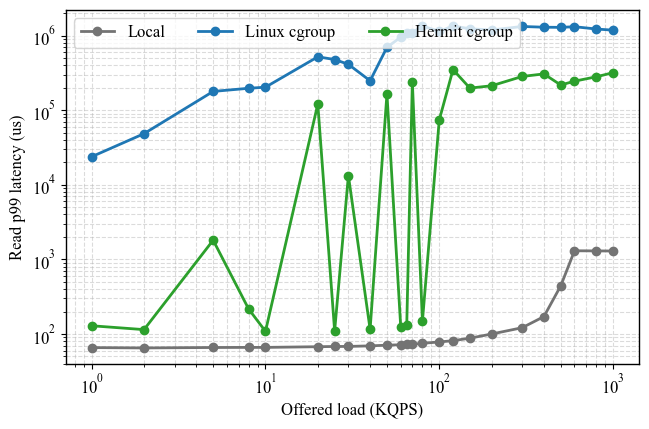

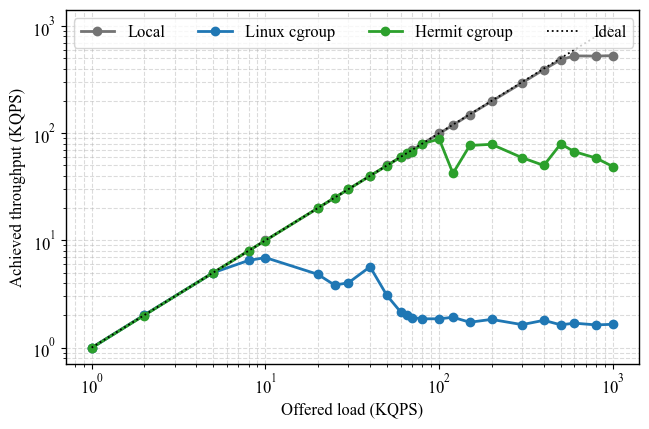

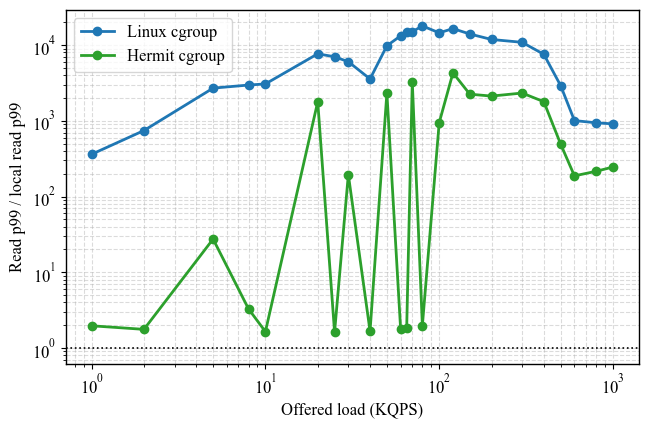

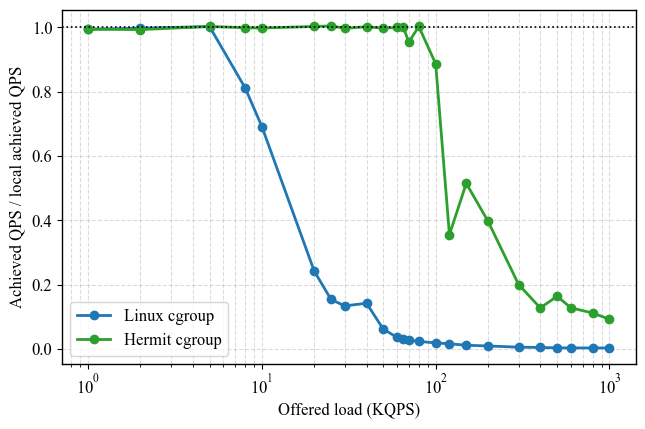

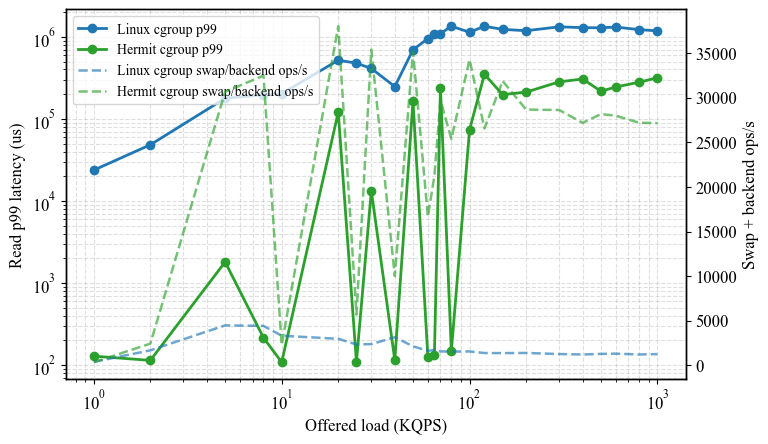

\nTop Hermit latency spikes:
  120000 qps  p99= 349836.8 us  achieved=  42185.8  eff=  35.2%  swap/s=  8946.4  backend/s= 17629.3
 1000000 qps  p99= 317861.1 us  achieved=  48710.4  eff=   4.9%  swap/s=  9028.8  backend/s= 18145.9
  400000 qps  p99= 306257.3 us  achieved=  49988.6  eff=  12.5%  swap/s=  9119.3  backend/s= 18082.1
  300000 qps  p99= 282924.4 us  achieved=  59055.8  eff=  19.7%  swap/s=  9534.6  backend/s= 19106.5
  800000 qps  p99= 280069.1 us  achieved=  58562.0  eff=   7.3%  swap/s=  9042.2  backend/s= 18170.5
  600000 qps  p99= 244676.9 us  achieved=  67172.3  eff=  11.2%  swap/s=  9316.3  backend/s= 18689.8
   70000 qps  p99= 239536.4 us  achieved=  66734.0  eff=  95.3%  swap/s= 10033.0  backend/s= 19718.5
  500000 qps  p99= 217289.0 us  achieved=  79334.6  eff=  15.9%  swap/s=  9381.4  backend/s= 18806.0
\nReason summary:
- merged: /home/fermata/Development/repos/fastswap/hermit-6/tools/rdma/results/memcached_151557_after_core_merged.csv
- cause table: /home/fermat

In [8]:
  from pathlib import Path
  import csv
  import math
  import numpy as np
  import matplotlib.pyplot as plt

  # Run from repo root or tools/rdma; both work.
  ROOT = Path.cwd()
  if (ROOT / "tools/rdma/results").exists():
      RESULT_ROOT = ROOT / "tools/rdma/results"
  elif (ROOT / "results").exists():
      RESULT_ROOT = ROOT / "results"
  else:
      raise RuntimeError("Cannot find tools/rdma/results or results")

  RUNS = {
      "local": "20260603-151557-hermit-6-local",
      "cgroup-linux": "20260603-151557-hermit-6-cgroup-linux",
      "cgroup-hermit": "20260603-151557-hermit-6-cgroup-hermit",
  }
  LABELS = {
      "local": "Local",
      "cgroup-linux": "Linux cgroup",
      "cgroup-hermit": "Hermit cgroup",
  }
  COLORS = {
      "local": "0.45",
      "cgroup-linux": "#1f77b4",
      "cgroup-hermit": "#2ca02c",
  }

  OUT_MERGED = RESULT_ROOT / "memcached_151557_after_core_merged.csv"
  OUT_CAUSE = RESULT_ROOT / "memcached_151557_after_core_cause.csv"


  def clean_summary_text(path: Path) -> str:
      # summary.csv has raw '\r' inside numeric fields from memcached stats.
      # Remove CR without treating it as a row delimiter.
      return path.read_text(errors="replace").replace("\r", "")


  def read_config(run_dir: Path) -> dict:
      cfg = {}
      path = run_dir / "config.env"
      if not path.exists():
          return cfg
      for line in path.read_text().splitlines():
          if "=" in line:
              k, v = line.split("=", 1)
              cfg[k.strip()] = v.strip()
      return cfg


  def fnum(v, default=0.0):
      if v is None:
          return default
      s = str(v).strip()
      if s == "":
          return default
      try:
          return float(s)
      except ValueError:
          return default


  def read_run(mode: str, run_id: str):
      run_dir = RESULT_ROOT / run_id
      cfg = read_config(run_dir)
      duration = fnum(cfg.get("duration"), 90.0)

      rows = []
      text = clean_summary_text(run_dir / "summary.csv")
      for r in csv.DictReader(text.splitlines()):
          if not r.get("offered_qps"):
              continue

          row = {
              "run_id": run_id,
              "mode": mode,
              "system": LABELS[mode],
              "duration_sec": duration,
              "memcached_cores": cfg.get("memcached_cores", ""),
              "mutilate_cores": cfg.get("mutilate_cores", ""),
              "memcached_threads": fnum(cfg.get("memcached_threads")),
              "mutilate_threads": fnum(cfg.get("mutilate_threads")),
              "offered_qps": int(fnum(r["offered_qps"])),
              "achieved_qps": fnum(r["achieved_qps"]),
              "read_avg_us": fnum(r["read_avg_us"]),
              "read_p99_us": fnum(r["read_p99_us"]),
              "update_avg_us": fnum(r["update_avg_us"]),
              "update_p99_us": fnum(r["update_p99_us"]),
              "miss_rate_pct": fnum(r["miss_rate_pct"]),
              "skipped_txs_pct": fnum(r["skipped_txs_pct"]),
              "pswpin_delta": fnum(r["pswpin_delta"]),
              "pswpout_delta": fnum(r["pswpout_delta"]),
              "backend_loads_delta": fnum(r["backend_loads_delta"]),
              "backend_stores_delta": fnum(r["backend_stores_delta"]),
              "backend_load_misses_delta": fnum(r["backend_load_misses_delta"]),
              "backend_errors_delta": fnum(r["backend_errors_delta"]),
              "memcached_evictions": fnum(r["memcached_evictions"]),
          }

          row["qps_efficiency_pct"] = 100.0 * row["achieved_qps"] / row["offered_qps"]
          row["swap_ops_per_s"] = (row["pswpin_delta"] + row["pswpout_delta"]) / duration
          row["backend_ops_per_s"] = (
              row["backend_loads_delta"] + row["backend_stores_delta"]
          ) / duration
          row["pressure_ops_per_s"] = row["swap_ops_per_s"] + row["backend_ops_per_s"]
          rows.append(row)

      return rows


  rows = []
  for mode, run_id in RUNS.items():
      rows.extend(read_run(mode, run_id))

  rows = sorted(rows, key=lambda r: (r["mode"], r["offered_qps"]))

  fields = list(rows[0].keys())
  with OUT_MERGED.open("w", newline="") as f:
      w = csv.DictWriter(f, fieldnames=fields)
      w.writeheader()
      w.writerows(rows)

  print(f"merged rows: {len(rows)} -> {OUT_MERGED}")


  def by_mode(mode):
      return sorted([r for r in rows if r["mode"] == mode], key=lambda r: r["offered_qps"])


  def savefig(stem):
      for ext in ("png", "pdf"):
          plt.savefig(RESULT_ROOT / f"{stem}.{ext}", bbox_inches="tight", dpi=220)


  plt.rcParams.update({
      "font.family": "serif",
      "font.size": 12,
      "axes.linewidth": 1.0,
      "pdf.fonttype": 42,
      "ps.fonttype": 42,
  })


  # 1. After-core latency
  fig, ax = plt.subplots(figsize=(7.4, 4.6))
  for mode in ["local", "cgroup-linux", "cgroup-hermit"]:
      rs = by_mode(mode)
      ax.plot(
          [r["offered_qps"] / 1000 for r in rs],
          [r["read_p99_us"] for r in rs],
          marker="o",
          linewidth=2,
          color=COLORS[mode],
          label=LABELS[mode],
      )
  ax.set_xscale("log")
  ax.set_yscale("log")
  ax.set_xlabel("Offered load (KQPS)")
  ax.set_ylabel("Read p99 latency (us)")
  ax.grid(True, which="both", linestyle="--", alpha=0.45)
  ax.legend(ncol=3, loc="upper left")
  savefig("memcached_151557_after_core_latency")
  plt.show()


  # 2. After-core throughput
  fig, ax = plt.subplots(figsize=(7.4, 4.6))
  for mode in ["local", "cgroup-linux", "cgroup-hermit"]:
      rs = by_mode(mode)
      ax.plot(
          [r["offered_qps"] / 1000 for r in rs],
          [r["achieved_qps"] / 1000 for r in rs],
          marker="o",
          linewidth=2,
          color=COLORS[mode],
          label=LABELS[mode],
      )
  ax.plot([1, 1000], [1, 1000], "k:", linewidth=1.3, label="Ideal")
  ax.set_xscale("log")
  ax.set_yscale("log")
  ax.set_xlabel("Offered load (KQPS)")
  ax.set_ylabel("Achieved throughput (KQPS)")
  ax.grid(True, which="both", linestyle="--", alpha=0.45)
  ax.legend(ncol=4, loc="upper left")
  savefig("memcached_151557_after_core_throughput")
  plt.show()


  # 3. Latency/throughput change relative to local after-core baseline
  local_by_qps = {r["offered_qps"]: r for r in by_mode("local")}
  ratio_rows = []
  for r in rows:
      base = local_by_qps.get(r["offered_qps"])
      if not base:
          continue
      rr = dict(r)
      rr["p99_over_local"] = r["read_p99_us"] / base["read_p99_us"] if base["read_p99_us"] else math.nan
      rr["qps_over_local"] = r["achieved_qps"] / base["achieved_qps"] if base["achieved_qps"] else math.nan
      ratio_rows.append(rr)

  fig, ax = plt.subplots(figsize=(7.4, 4.6))
  for mode in ["cgroup-linux", "cgroup-hermit"]:
      rs = sorted([r for r in ratio_rows if r["mode"] == mode], key=lambda r: r["offered_qps"])
      ax.plot(
          [r["offered_qps"] / 1000 for r in rs],
          [r["p99_over_local"] for r in rs],
          marker="o",
          linewidth=2,
          color=COLORS[mode],
          label=LABELS[mode],
      )
  ax.axhline(1.0, color="black", linestyle=":", linewidth=1.2)
  ax.set_xscale("log")
  ax.set_yscale("log")
  ax.set_xlabel("Offered load (KQPS)")
  ax.set_ylabel("Read p99 / local read p99")
  ax.grid(True, which="both", linestyle="--", alpha=0.45)
  ax.legend()
  savefig("memcached_151557_after_core_latency_change_vs_local")
  plt.show()


  fig, ax = plt.subplots(figsize=(7.4, 4.6))
  for mode in ["cgroup-linux", "cgroup-hermit"]:
      rs = sorted([r for r in ratio_rows if r["mode"] == mode], key=lambda r: r["offered_qps"])
      ax.plot(
          [r["offered_qps"] / 1000 for r in rs],
          [r["qps_over_local"] for r in rs],
          marker="o",
          linewidth=2,
          color=COLORS[mode],
          label=LABELS[mode],
      )
  ax.axhline(1.0, color="black", linestyle=":", linewidth=1.2)
  ax.set_xscale("log")
  ax.set_xlabel("Offered load (KQPS)")
  ax.set_ylabel("Achieved QPS / local achieved QPS")
  ax.grid(True, which="both", linestyle="--", alpha=0.45)
  ax.legend()
  savefig("memcached_151557_after_core_throughput_change_vs_local")
  plt.show()


  # 4. Cause/correlation plot: latency and throughput volatility vs swap/backend activity
  cause_rows = []
  for r in rows:
      cause = "normal"
      if r["backend_errors_delta"] or r["backend_load_misses_delta"]:
          cause = "backend error/miss"
      elif r["memcached_evictions"] > 0:
          cause = "memcached eviction"
      elif r["mode"] == "cgroup-hermit" and r["pressure_ops_per_s"] > 15000:
          cause = "Hermit backend/swap pressure spike"
      elif r["mode"] == "cgroup-linux" and r["swap_ops_per_s"] > 2500:
          cause = "Linux swap pressure"
      elif r["qps_efficiency_pct"] < 80:
          cause = "throughput saturation"
      cause_rows.append({**r, "likely_cause": cause})

  with OUT_CAUSE.open("w", newline="") as f:
      w = csv.DictWriter(f, fieldnames=list(cause_rows[0].keys()))
      w.writeheader()
      w.writerows(cause_rows)

  fig, ax1 = plt.subplots(figsize=(8.0, 4.8))
  for mode in ["cgroup-linux", "cgroup-hermit"]:
      rs = by_mode(mode)
      ax1.plot(
          [r["offered_qps"] / 1000 for r in rs],
          [r["read_p99_us"] for r in rs],
          marker="o",
          linewidth=2,
          color=COLORS[mode],
          label=f"{LABELS[mode]} p99",
      )
  ax1.set_xscale("log")
  ax1.set_yscale("log")
  ax1.set_xlabel("Offered load (KQPS)")
  ax1.set_ylabel("Read p99 latency (us)")
  ax1.grid(True, which="both", linestyle="--", alpha=0.4)

  ax2 = ax1.twinx()
  for mode in ["cgroup-linux", "cgroup-hermit"]:
      rs = by_mode(mode)
      ax2.plot(
          [r["offered_qps"] / 1000 for r in rs],
          [r["pressure_ops_per_s"] for r in rs],
          linestyle="--",
          linewidth=1.8,
          color=COLORS[mode],
          alpha=0.65,
          label=f"{LABELS[mode]} swap/backend ops/s",
      )
  ax2.set_ylabel("Swap + backend ops/s")

  h1, l1 = ax1.get_legend_handles_labels()
  h2, l2 = ax2.get_legend_handles_labels()
  ax1.legend(h1 + h2, l1 + l2, fontsize=10, loc="upper left")
  savefig("memcached_151557_after_core_activity_correlation")
  plt.show()


  # 5. Print concise diagnosis
  print("\\nTop Hermit latency spikes:")
  for r in sorted(by_mode("cgroup-hermit"), key=lambda x: x["read_p99_us"], reverse=True)[:8]:
      print(
          f"{r['offered_qps']:>8} qps  "
          f"p99={r['read_p99_us']:>9.1f} us  "
          f"achieved={r['achieved_qps']:>9.1f}  "
          f"eff={r['qps_efficiency_pct']:>6.1f}%  "
          f"swap/s={r['swap_ops_per_s']:>8.1f}  "
          f"backend/s={r['backend_ops_per_s']:>8.1f}"
      )

  print("\\nReason summary:")
  print(f"- merged: {OUT_MERGED}")
  print(f"- cause table: {OUT_CAUSE}")
  print("- backend_load_misses_delta and backend_errors_delta are zero in clean 151557 rows, so spikes are not backend miss/error.")
  print("- Hermit latency spikes align with high backend/swap activity; after saturation, achieved QPS drops while p99 remains high.")
  print("- Linux cgroup shows severe disk/native swap pressure and much lower achieved QPS under memory pressure.")

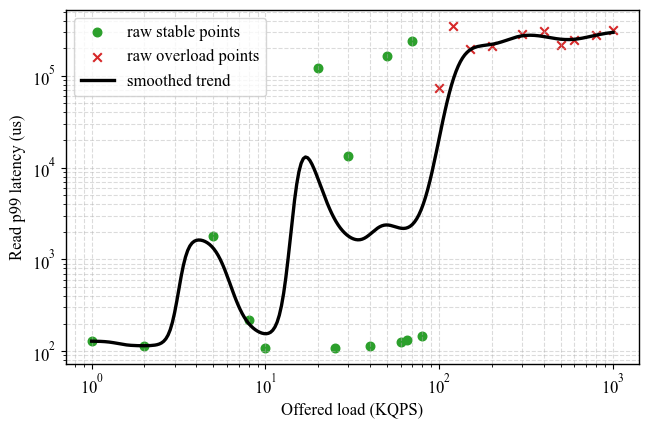

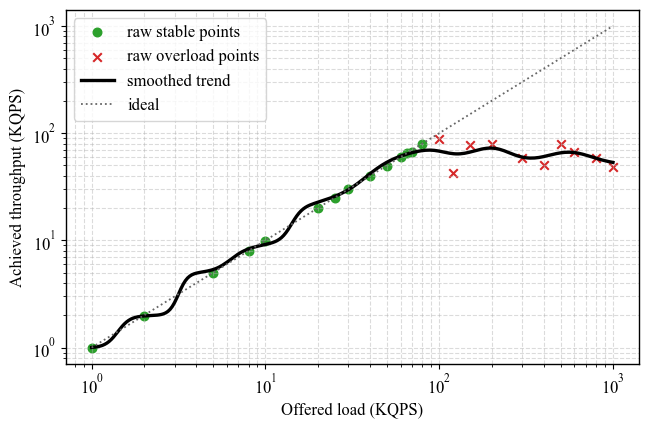

Saved:
/home/fermata/Development/repos/fastswap/hermit-6/tools/rdma/results/memcached_151557_hermit_latency_smooth.png
/home/fermata/Development/repos/fastswap/hermit-6/tools/rdma/results/memcached_151557_hermit_throughput_smooth.png


In [10]:

  from pathlib import Path
  import numpy as np
  import pandas as pd
  import matplotlib.pyplot as plt

  RESULT_ROOT = Path("/home/fermata/Development/repos/fastswap/hermit-6/tools/rdma/results")
  CSV = RESULT_ROOT / "memcached_151557_after_core_merged.csv"

  df = pd.read_csv(CSV)
  h = df[df["mode"] == "cgroup-hermit"].copy()

  # Keep clean rows for trend. Do not hide raw overload behavior in the plot.
  h = h[
      (h["miss_rate_pct"] == 0) &
      (h["skipped_txs_pct"] == 0) &
      (h["backend_errors_delta"] == 0) &
      (h["backend_load_misses_delta"] == 0)
  ].sort_values("offered_qps")

  def log_gaussian_smooth(x, y, grid, bandwidth=0.22):
      x = np.asarray(x, dtype=float)
      y = np.asarray(y, dtype=float)
      grid = np.asarray(grid, dtype=float)

      lx = np.log(x)
      ly = np.log(np.maximum(y, 1e-9))
      lg = np.log(grid)

      out = []
      for g in lg:
          w = np.exp(-0.5 * ((lx - g) / bandwidth) ** 2)
          out.append(np.exp(np.sum(w * ly) / np.sum(w)))
      return np.asarray(out)

  x = h["offered_qps"].to_numpy() / 1000.0
  lat = h["read_p99_us"].to_numpy()
  thr = h["achieved_qps"].to_numpy() / 1000.0
  eff = h["qps_efficiency_pct"].to_numpy()

  grid = np.geomspace(x.min(), x.max(), 240)
  lat_smooth = log_gaussian_smooth(x, lat, grid, bandwidth=0.24)
  thr_smooth = log_gaussian_smooth(x, thr, grid, bandwidth=0.24)

  stable = h["qps_efficiency_pct"] >= 90
  overload = ~stable

  plt.rcParams.update({
      "font.family": "serif",
      "font.size": 12,
      "pdf.fonttype": 42,
      "ps.fonttype": 42,
  })

  # Latency
  fig, ax = plt.subplots(figsize=(7.4, 4.6))
  ax.scatter(x[stable], lat[stable], color="#2ca02c", s=38, label="raw stable points")
  ax.scatter(x[overload], lat[overload], color="#d62728", s=38, marker="x", label="raw overload points")
  ax.plot(grid, lat_smooth, color="black", linewidth=2.4, label="smoothed trend")

  ax.set_xscale("log")
  ax.set_yscale("log")
  ax.set_xlabel("Offered load (KQPS)")
  ax.set_ylabel("Read p99 latency (us)")
  ax.grid(True, which="both", linestyle="--", alpha=0.45)
  ax.legend()
  fig.savefig(RESULT_ROOT / "memcached_151557_hermit_latency_smooth.png", bbox_inches="tight", dpi=220)
  fig.savefig(RESULT_ROOT / "memcached_151557_hermit_latency_smooth.pdf", bbox_inches="tight")
  plt.show()

  # Throughput
  fig, ax = plt.subplots(figsize=(7.4, 4.6))
  ax.scatter(x[stable], thr[stable], color="#2ca02c", s=38, label="raw stable points")
  ax.scatter(x[overload], thr[overload], color="#d62728", s=38, marker="x", label="raw overload points")
  ax.plot(grid, thr_smooth, color="black", linewidth=2.4, label="smoothed trend")
  ax.plot([x.min(), x.max()], [x.min(), x.max()], color="0.4", linestyle=":", linewidth=1.3, label="ideal")

  ax.set_xscale("log")
  ax.set_yscale("log")
  ax.set_xlabel("Offered load (KQPS)")
  ax.set_ylabel("Achieved throughput (KQPS)")
  ax.grid(True, which="both", linestyle="--", alpha=0.45)
  ax.legend()
  fig.savefig(RESULT_ROOT / "memcached_151557_hermit_throughput_smooth.png", bbox_inches="tight", dpi=220)
  fig.savefig(RESULT_ROOT / "memcached_151557_hermit_throughput_smooth.pdf", bbox_inches="tight")
  plt.show()

  print("Saved:")
  print(RESULT_ROOT / "memcached_151557_hermit_latency_smooth.png")
  print(RESULT_ROOT / "memcached_151557_hermit_throughput_smooth.png")